# Visualização + Propriedades da rede de colaboração UNIFEI — por instituto

Usa os arquivos que você já tem prontos:
- `nodes.csv` (pesquisador + instituto)
- `edges.csv` (colaborações/coautorias)

Gera:
1. Um gráfico geral (maior componente conectado, colorido por instituto)
2. Um gráfico por instituto, só com colaboração **intra-instituto**
3. **Propriedades estruturais** de cada rede (geral e por instituto), no mesmo
   padrão da AT2 (Q6–Q12): nós, links, densidade, grau médio, distância média,
   diâmetro, coeficientes de agrupamento local/médio/global, componentes
   conexos, pontos de articulação, pontes e Lei de Metcalfe.
4. Um **relatório de qualidade dos dados** (nulos, self-loops, arestas
   duplicadas, pesos inválidos)
5. Histogramas de grau e de peso das arestas — geral e por instituto.
6. Uma tabela comparativa (CSV) com as métricas de todos os institutos.
7. Download de tudo (figuras + CSV de estatísticas) em um único `.zip`.


In [ ]:
!pip install adjustText -q
!pip install igraph -q
!pip install matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 27.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from adjustText import adjust_text
import time
import math
import os
import igraph as ig

from google.colab import drive
drive.mount("/content/drive")

nodes = pd.read_csv("/content/drive/MyDrive/nodes.csv")
edges = pd.read_csv("/content/drive/MyDrive/edges.csv")

INSTITUTOS = ["IEM", "IEPG", "IESTI", "IFQ", "IMC", "IRN", "ISEE", "IEI"]

CORES = {
    "IEM":  "#e6194B",
    "IEPG": "#3cb44b",
    "IESTI":"#4363d8",
    "IFQ":  "#f58231",
    "IMC":  "#911eb4",
    "IRN":  "#42d4f4",
    "ISEE": "#f032e6",
    "IEI":  "#9acd32",
    "Não identificado": "#c9c9c9",
}

def instituto_principal(valor):
    # Se o pesquisador tem mais de um instituto (separado por ';'),
    # usamos o primeiro só para fins de cor no grafo geral.
    if pd.isna(valor):
        return "Não identificado"
    return valor.split(";")[0].strip()

nodes["instituto_cor"] = nodes["instituto"].apply(instituto_principal)

os.makedirs("/content/figuras", exist_ok=True)

print("Nós:", len(nodes), "| Arestas:", len(edges))

Mounted at /content/drive
Nós: 3938 | Arestas: 11410


## 0. Relatório de qualidade dos dados

Mesma checagem da **Q13** da AT2, aplicada a `nodes.csv` / `edges.csv`: valores
ausentes, *self-loops*, arestas duplicadas, pesos inválidos (zero ou
negativos) e nós isolados.

In [ ]:
# ============================================================
# RELATÓRIO DE QUALIDADE DOS DADOS (nodes.csv / edges.csv)
# ============================================================

problemas = []

# 1) Valores ausentes
problemas.append(("Valores ausentes em nodes.csv", int(nodes.isna().sum().sum())))
problemas.append(("Valores ausentes em edges.csv", int(edges.isna().sum().sum())))

# 2) Self-loops (source == target)
n_selfloops = int((edges["source"] == edges["target"]).sum())
problemas.append(("Self-loops (source == target)", n_selfloops))

# 3) Arestas duplicadas (mesmo par, ignorando direção)
pares = edges.apply(lambda r: tuple(sorted([r["source"], r["target"]])), axis=1)
n_duplicadas = int(pares.duplicated().sum())
problemas.append(("Arestas duplicadas (mesmo par)", n_duplicadas))

# 4) Pesos inválidos (zero ou negativos)
n_pesos_invalidos = int((edges["weight"] <= 0).sum())
problemas.append(("Pesos inválidos (<= 0)", n_pesos_invalidos))

# 5) Nós referenciados em edges.csv que não existem em nodes.csv
ids_nodes = set(nodes["id"])
ids_edges = set(edges["source"]) | set(edges["target"])
n_orfaos = len(ids_edges - ids_nodes)
problemas.append(("Ids em edges.csv ausentes em nodes.csv", n_orfaos))

# 6) Nós isolados (sem nenhuma aresta)
n_isolados = len(ids_nodes - ids_edges)
problemas.append(("Nós isolados (sem nenhuma colaboração)", n_isolados))

relatorio_qualidade = pd.DataFrame(problemas, columns=["Verificação", "Ocorrências"])
display(relatorio_qualidade)
relatorio_qualidade.to_csv("/content/figuras/00_relatorio_qualidade.csv", index=False)

,Verificação,Ocorrências
0,Valores ausentes em nodes.csv,0
1,Valores ausentes em edges.csv,0
2,Self-loops (source == target),0
3,Arestas duplicadas (mesmo par),0
4,Pesos inválidos (<= 0),0
5,Ids em edges.csv ausentes em nodes.csv,0
6,Nós isolados (sem nenhuma colaboração),332


## 1. Gráfico geral (maior componente, colorido por instituto)

Maior componente: 2987 de 3938 nós
Número de componentes: 496


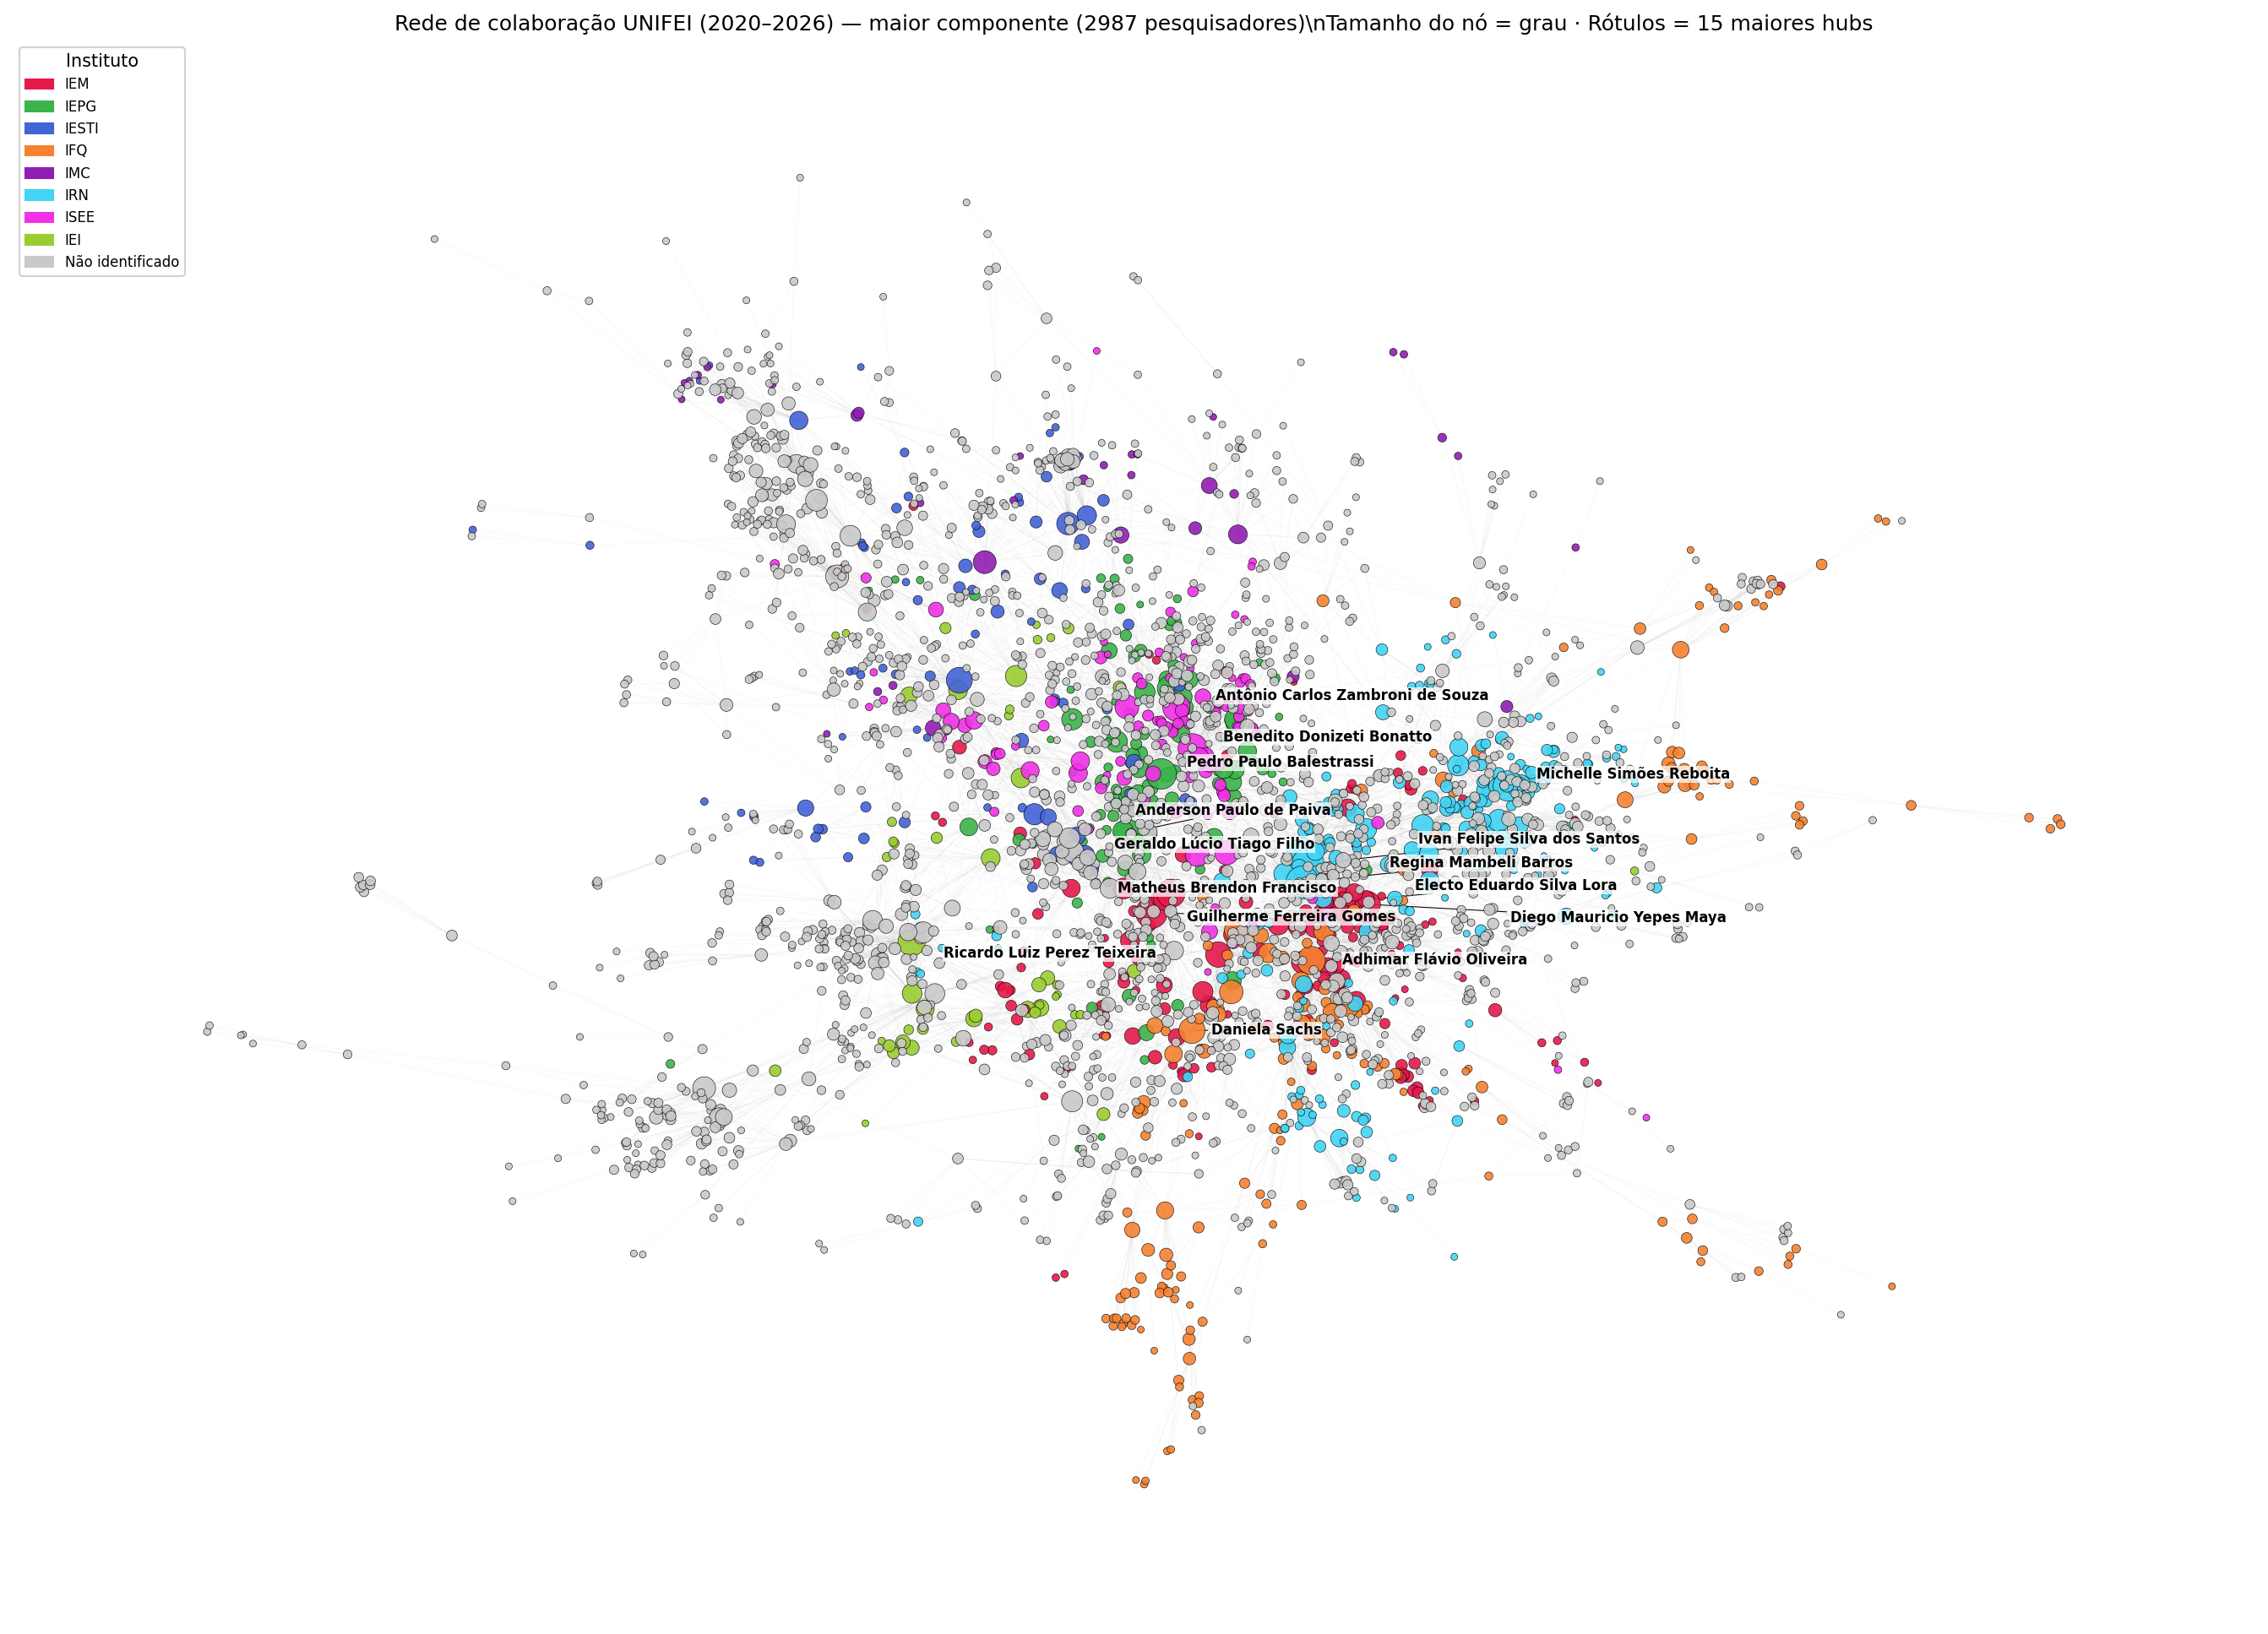

In [ ]:
G = nx.Graph()
for _, row in nodes.iterrows():
    G.add_node(row["id"], label=row["label"], instituto=row["instituto_cor"])
for _, row in edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Trabalhar só com o maior componente conectado deixa o layout muito
# mais legível (nós isolados/componentes pequenos só atrapalham a leitura)
componentes = sorted(nx.connected_components(G), key=len, reverse=True)
print("Maior componente:", len(componentes[0]), "de", G.number_of_nodes(), "nós")
print("Número de componentes:", len(componentes))

Gc = G.subgraph(componentes[0]).copy()

pos = nx.spring_layout(Gc, k=1.4/np.sqrt(Gc.number_of_nodes()), iterations=100, seed=42)

graus = dict(Gc.degree())
top_hubs = sorted(graus, key=graus.get, reverse=True)[:15]

fig, ax = plt.subplots(figsize=(18, 13), dpi=150)

node_colors = [CORES.get(Gc.nodes[n]["instituto"], "#999999") for n in Gc.nodes()]
node_sizes = [12 + 3.2 * graus[n] for n in Gc.nodes()]

nx.draw_networkx_edges(Gc, pos, ax=ax, alpha=0.05, width=0.5, edge_color="gray")
nx.draw_networkx_nodes(Gc, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                        linewidths=0.3, edgecolors="black", alpha=0.9)

texts = []
for n in top_hubs:
    x, y = pos[n]
    texts.append(ax.text(x, y, Gc.nodes[n]["label"], fontsize=8, fontweight="bold",
                          bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.5)))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="black", lw=0.5))

legend_handles = [mpatches.Patch(color=CORES[i], label=i) for i in INSTITUTOS + ["Não identificado"]]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, framealpha=0.9, title="Instituto")
ax.set_title(f"Rede de colaboração UNIFEI (2020–2026) — maior componente ({Gc.number_of_nodes()} pesquisadores)\\n"
             f"Tamanho do nó = grau · Rótulos = 15 maiores hubs", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/figuras/00_rede_geral_por_instituto.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.1 Propriedades estruturais — rede geral

Mesmas métricas da AT2 (Q6–Q12), calculadas sobre **G** (rede completa, com
todos os componentes) e sobre o **maior componente (Gc)**, que é onde
distância média e diâmetro fazem sentido (essas duas métricas exigem um grafo
conexo).

In [ ]:
def propriedades_rede(Grafo, nome):
    # Replica as métricas da AT2 (Q6 a Q12) para um grafo networkx qualquer.
    n = Grafo.number_of_nodes()
    m = Grafo.number_of_edges()
    densidade = nx.density(Grafo)
    grau_medio = (2 * m / n) if n > 0 else 0.0

    n_componentes = nx.number_connected_components(Grafo) if n > 0 else 0
    maior_comp = max(nx.connected_components(Grafo), key=len) if n > 0 else set()
    Gg = Grafo.subgraph(maior_comp).copy()

    if Gg.number_of_nodes() > 1:
        diametro = nx.diameter(Gg)
        dist_media = nx.average_shortest_path_length(Gg)
    else:
        diametro = 0
        dist_media = 0.0

    ca_local = nx.clustering(Grafo)
    ca_medio = nx.average_clustering(Grafo) if n > 0 else 0.0
    ca_global = nx.transitivity(Grafo)

    pontos_articulacao = list(nx.articulation_points(Grafo)) if n > 0 else []
    pontes = list(nx.bridges(Grafo)) if n > 0 else []

    valor_metcalfe = n ** 2

    return {
        "Rede": nome,
        "Nós": n,
        "Links": m,
        "Links (completo)": int(n * (n - 1) / 2) if n > 0 else 0,
        "Densidade": round(densidade, 4),
        "Grau médio <k>": round(grau_medio, 4),
        "Nº componentes conexos": n_componentes,
        "Distância média <d> (maior comp.)": round(dist_media, 4),
        "Diâmetro (maior comp.)": diametro,
        "Coef. Agrupamento Médio": round(ca_medio, 4),
        "Coef. Agrupamento Global": round(ca_global, 4),
        "Nº pontos de articulação": len(pontos_articulacao),
        "Nº arestas-ponte": len(pontes),
        "Valor da rede (Metcalfe)": valor_metcalfe,
        "_ca_local": ca_local,
        "_pontos_articulacao": pontos_articulacao,
        "_pontes": pontes,
    }

props_geral = propriedades_rede(G, "Geral (todos os componentes)")
props_gc = propriedades_rede(Gc, "Geral (maior componente)")

resumo_geral = pd.DataFrame([props_geral, props_gc]).drop(
    columns=["_ca_local", "_pontos_articulacao", "_pontes"]
)
display(resumo_geral)

print("\\nPontos de articulação (maior componente):", len(props_gc["_pontos_articulacao"]))
print("Arestas-ponte (maior componente):", len(props_gc["_pontes"]))

,Rede,Nós,Links,Links (completo),Densidade,Grau médio <k>,Nº componentes conexos,Distância média <d> (maior comp.),Diâmetro (maior comp.),Coef. Agrupamento Médio,Coef. Agrupamento Global,Nº pontos de articulação,Nº arestas-ponte,Valor da rede (Metcalfe)
0,Geral (todos os componentes),3938,11410,7751953,0.0015,5.7948,496,5.034,13,0.6264,0.2675,301,465,15507844
1,Geral (maior componente),2987,10432,4459591,0.0023,6.9849,1,5.034,13,0.6955,0.2569,268,350,8922169


\nPontos de articulação (maior componente): 268
Arestas-ponte (maior componente): 350


### Distribuição de grau e de peso — rede geral

Histogramas equivalentes à AT2 (Q14–Q15).

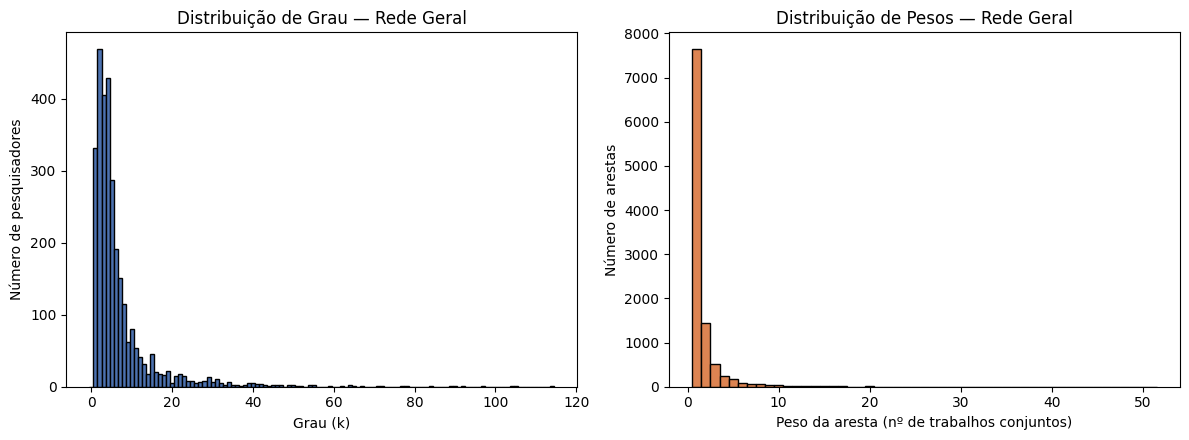

Grau médio: 6.985 | Grau máximo: 114
Peso médio: 1.732 | Peso máximo: 51


In [ ]:
# ============================================================
# HISTOGRAMAS: GRAU e PESO — REDE GERAL (maior componente)
# ============================================================

graus_lista = [d for _, d in Gc.degree()]
pesos_lista = [d["weight"] for _, _, d in Gc.edges(data=True)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(graus_lista, bins=range(0, max(graus_lista) + 2), color="#4C72B0",
             edgecolor="black", align="left")
axes[0].set_xlabel("Grau (k)")
axes[0].set_ylabel("Número de pesquisadores")
axes[0].set_title("Distribuição de Grau — Rede Geral")

axes[1].hist(pesos_lista, bins=range(1, max(pesos_lista) + 2), color="#DD8452",
             edgecolor="black", align="left")
axes[1].set_xlabel("Peso da aresta (nº de trabalhos conjuntos)")
axes[1].set_ylabel("Número de arestas")
axes[1].set_title("Distribuição de Pesos — Rede Geral")

plt.tight_layout()
plt.savefig("/content/figuras/01_distribuicao_geral.png", dpi=300)
plt.show()

print(f"Grau médio: {np.mean(graus_lista):.3f} | Grau máximo: {max(graus_lista)}")
print(f"Peso médio: {np.mean(pesos_lista):.3f} | Peso máximo: {max(pesos_lista)}")

## 2. Gráfico e propriedades por instituto (colaboração intra-instituto)

Cada gráfico usa **apenas as arestas entre pesquisadores do mesmo instituto**
— isso reduz muito o tamanho da rede e deixa o layout legível. Pesquisadores
sem nenhuma coautoria dentro do próprio instituto (só colaboram fora) ficam de
fora do desenho, mas são contados no título.

Para cada instituto também calculamos as mesmas propriedades estruturais da
AT2 (Q6–Q12), guardadas ao final em uma tabela comparativa.

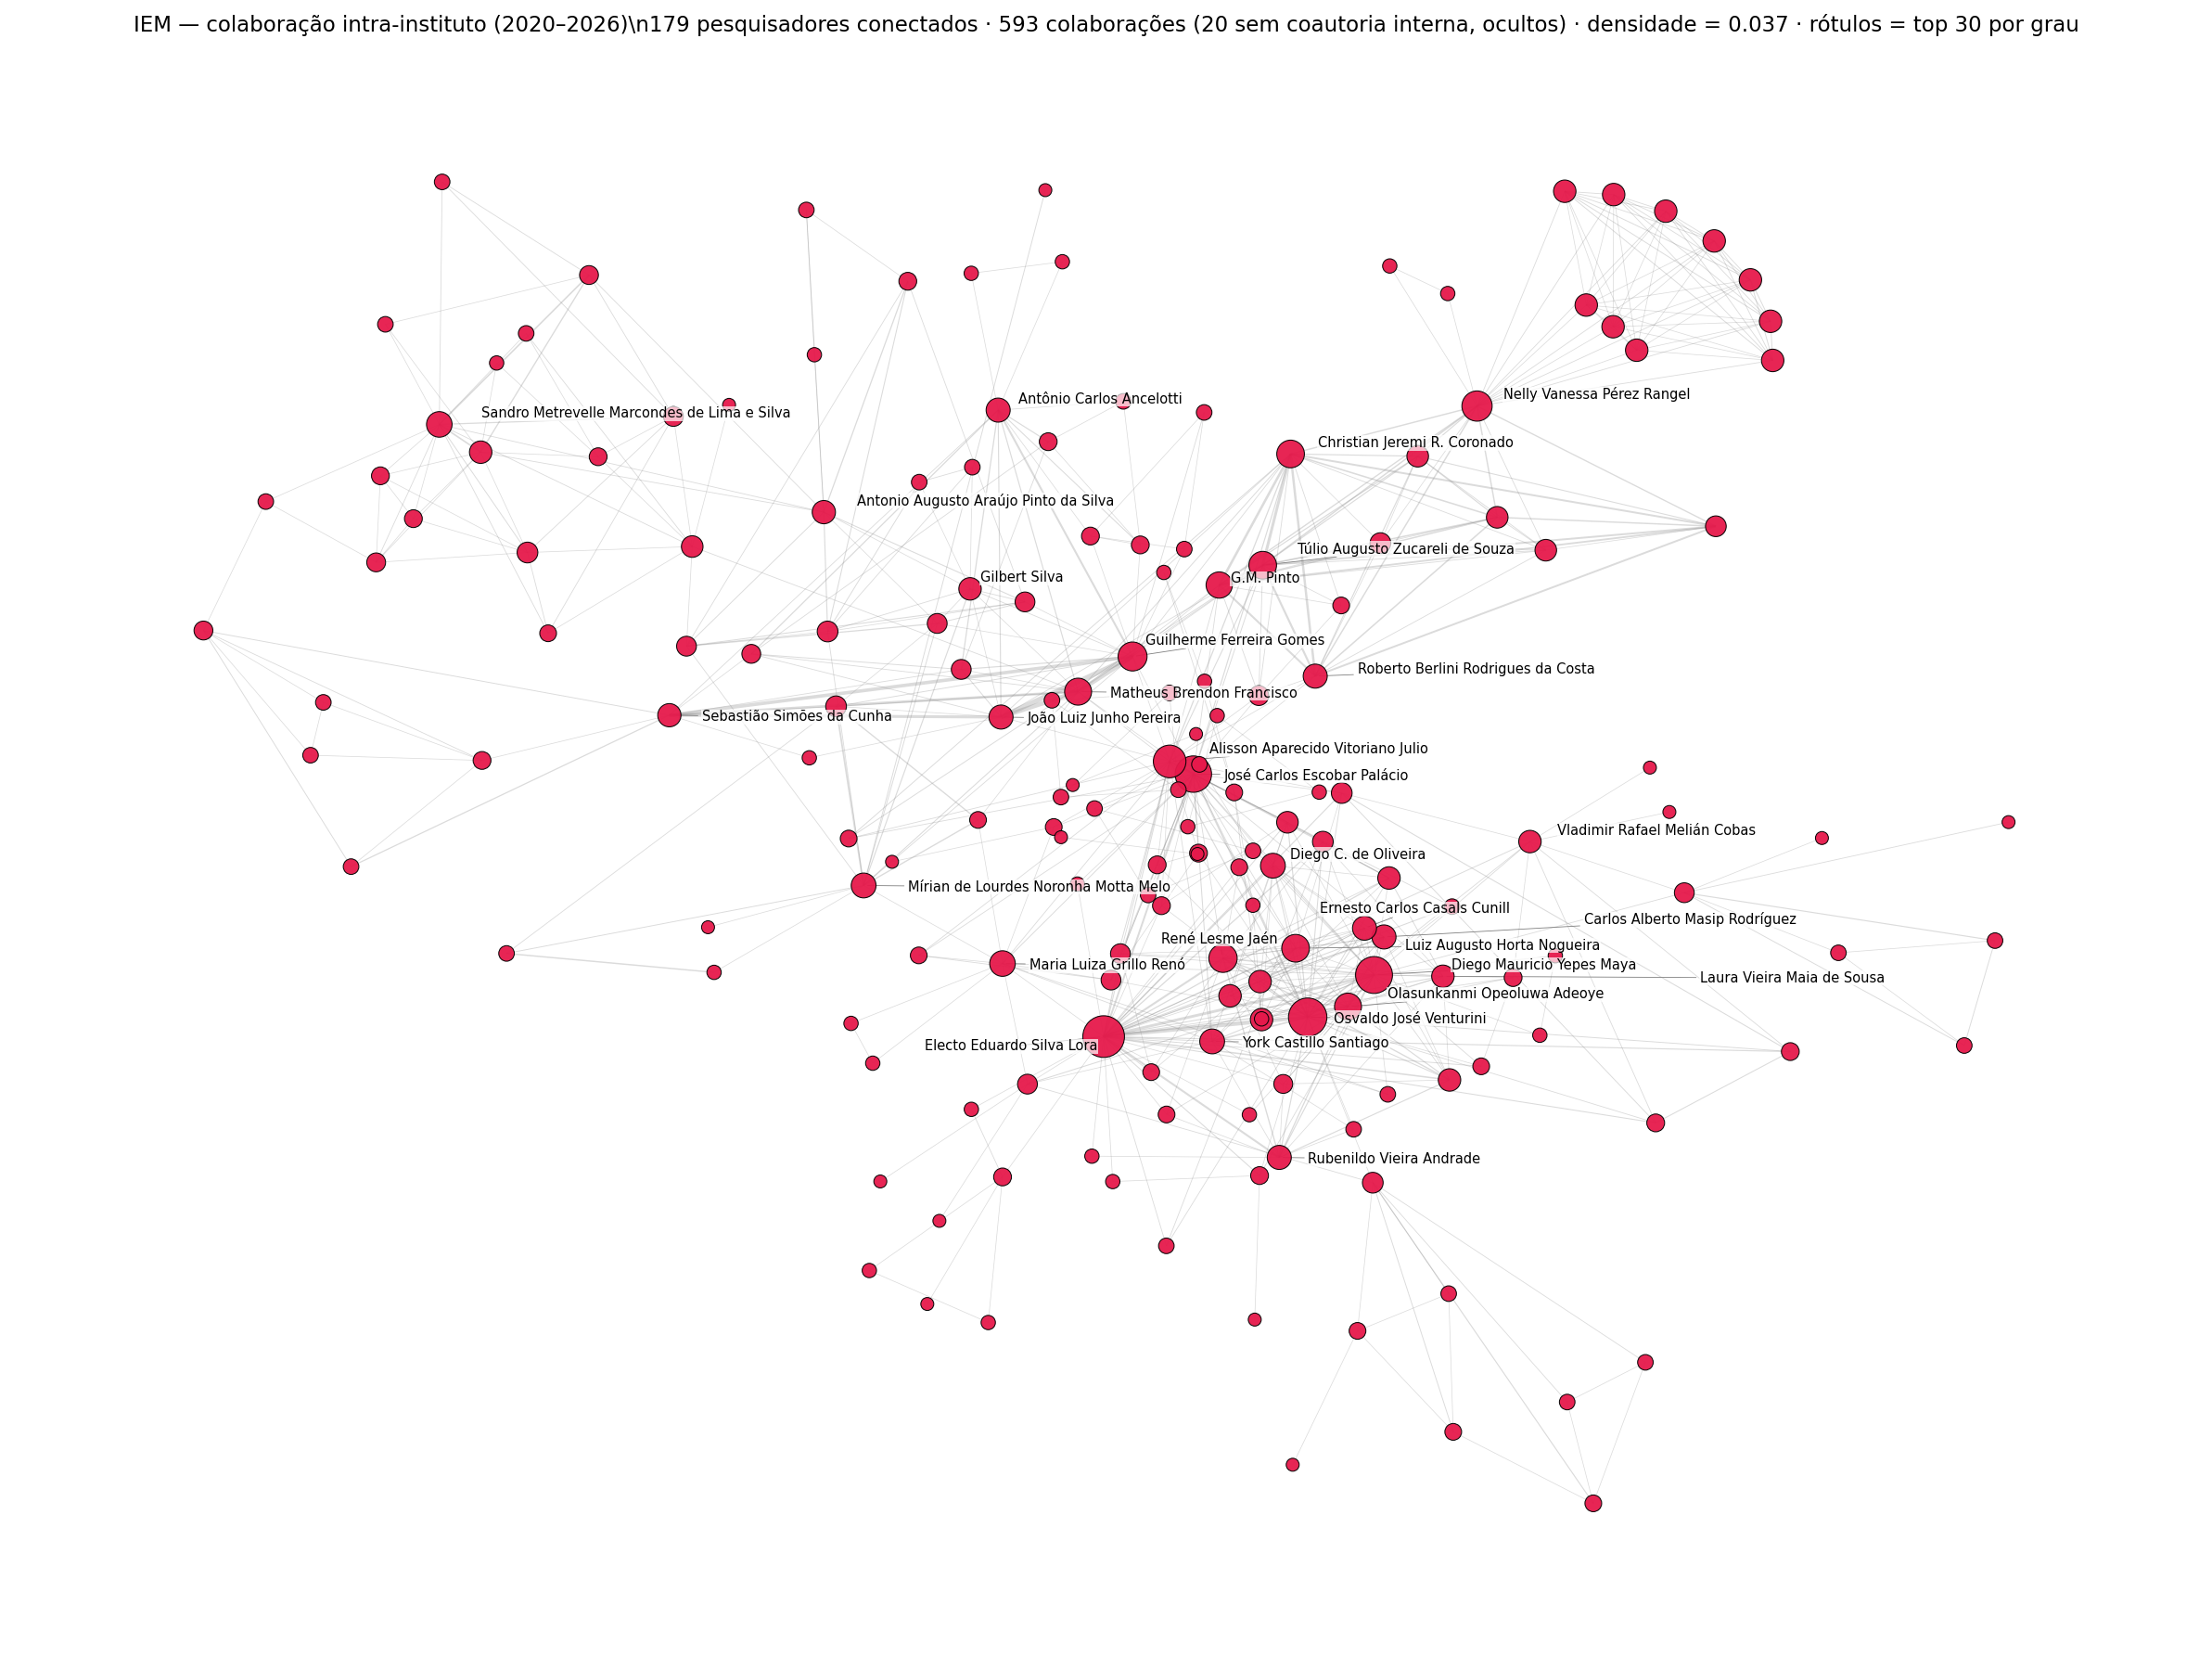

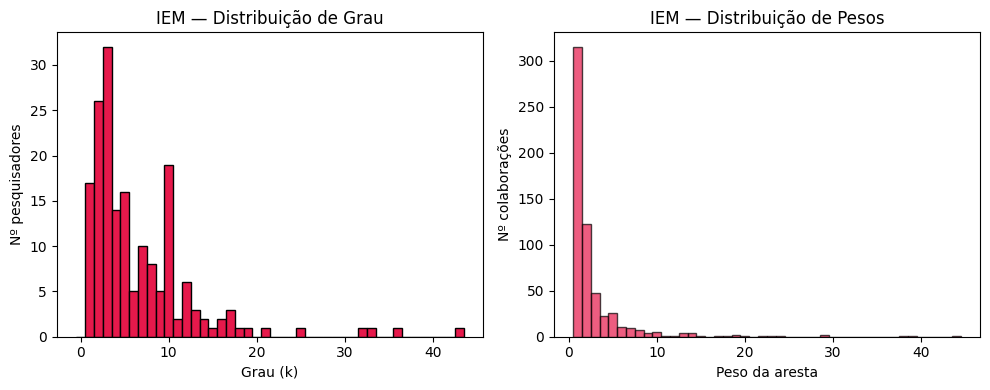

Salvo: IEM_rede.png e IEM_distribuicao.png (179 nós, 593 arestas)\n


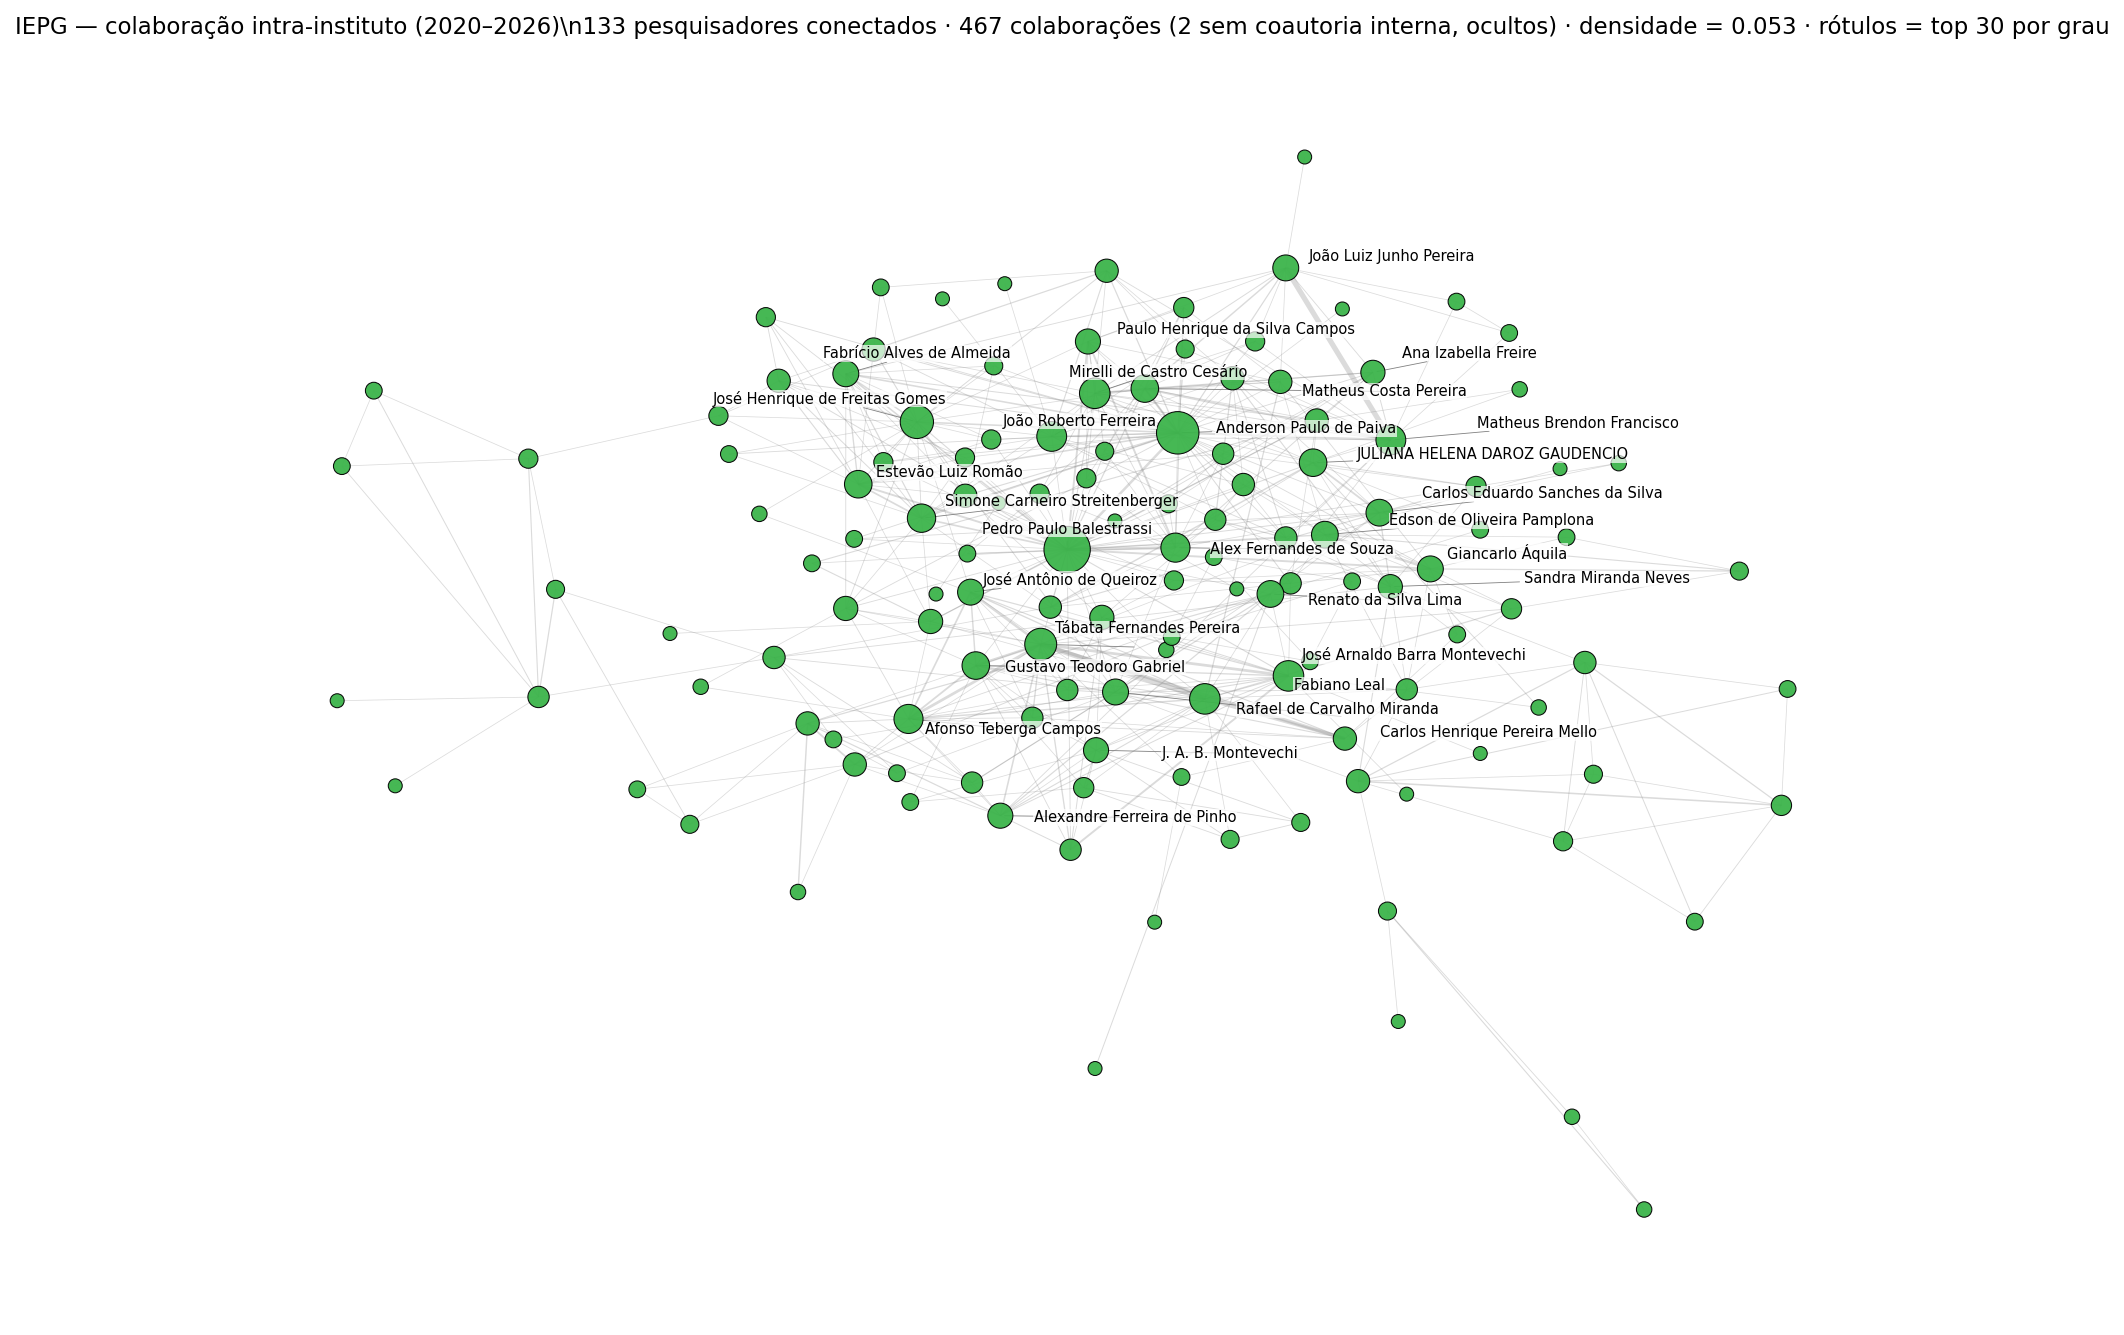

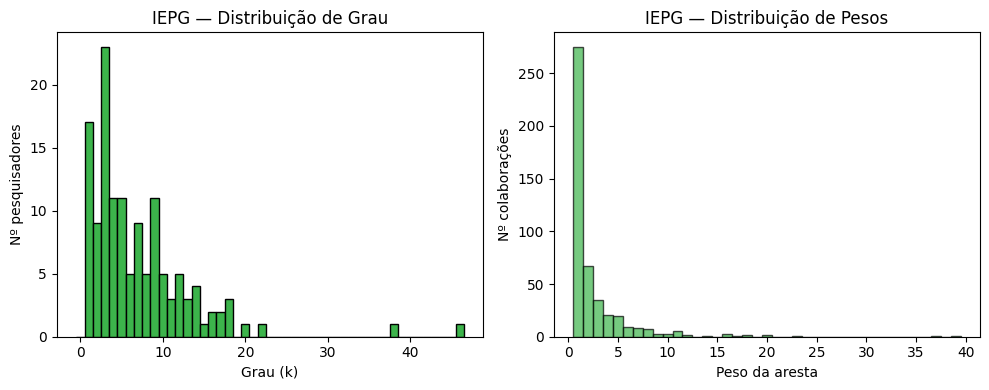

Salvo: IEPG_rede.png e IEPG_distribuicao.png (133 nós, 467 arestas)\n


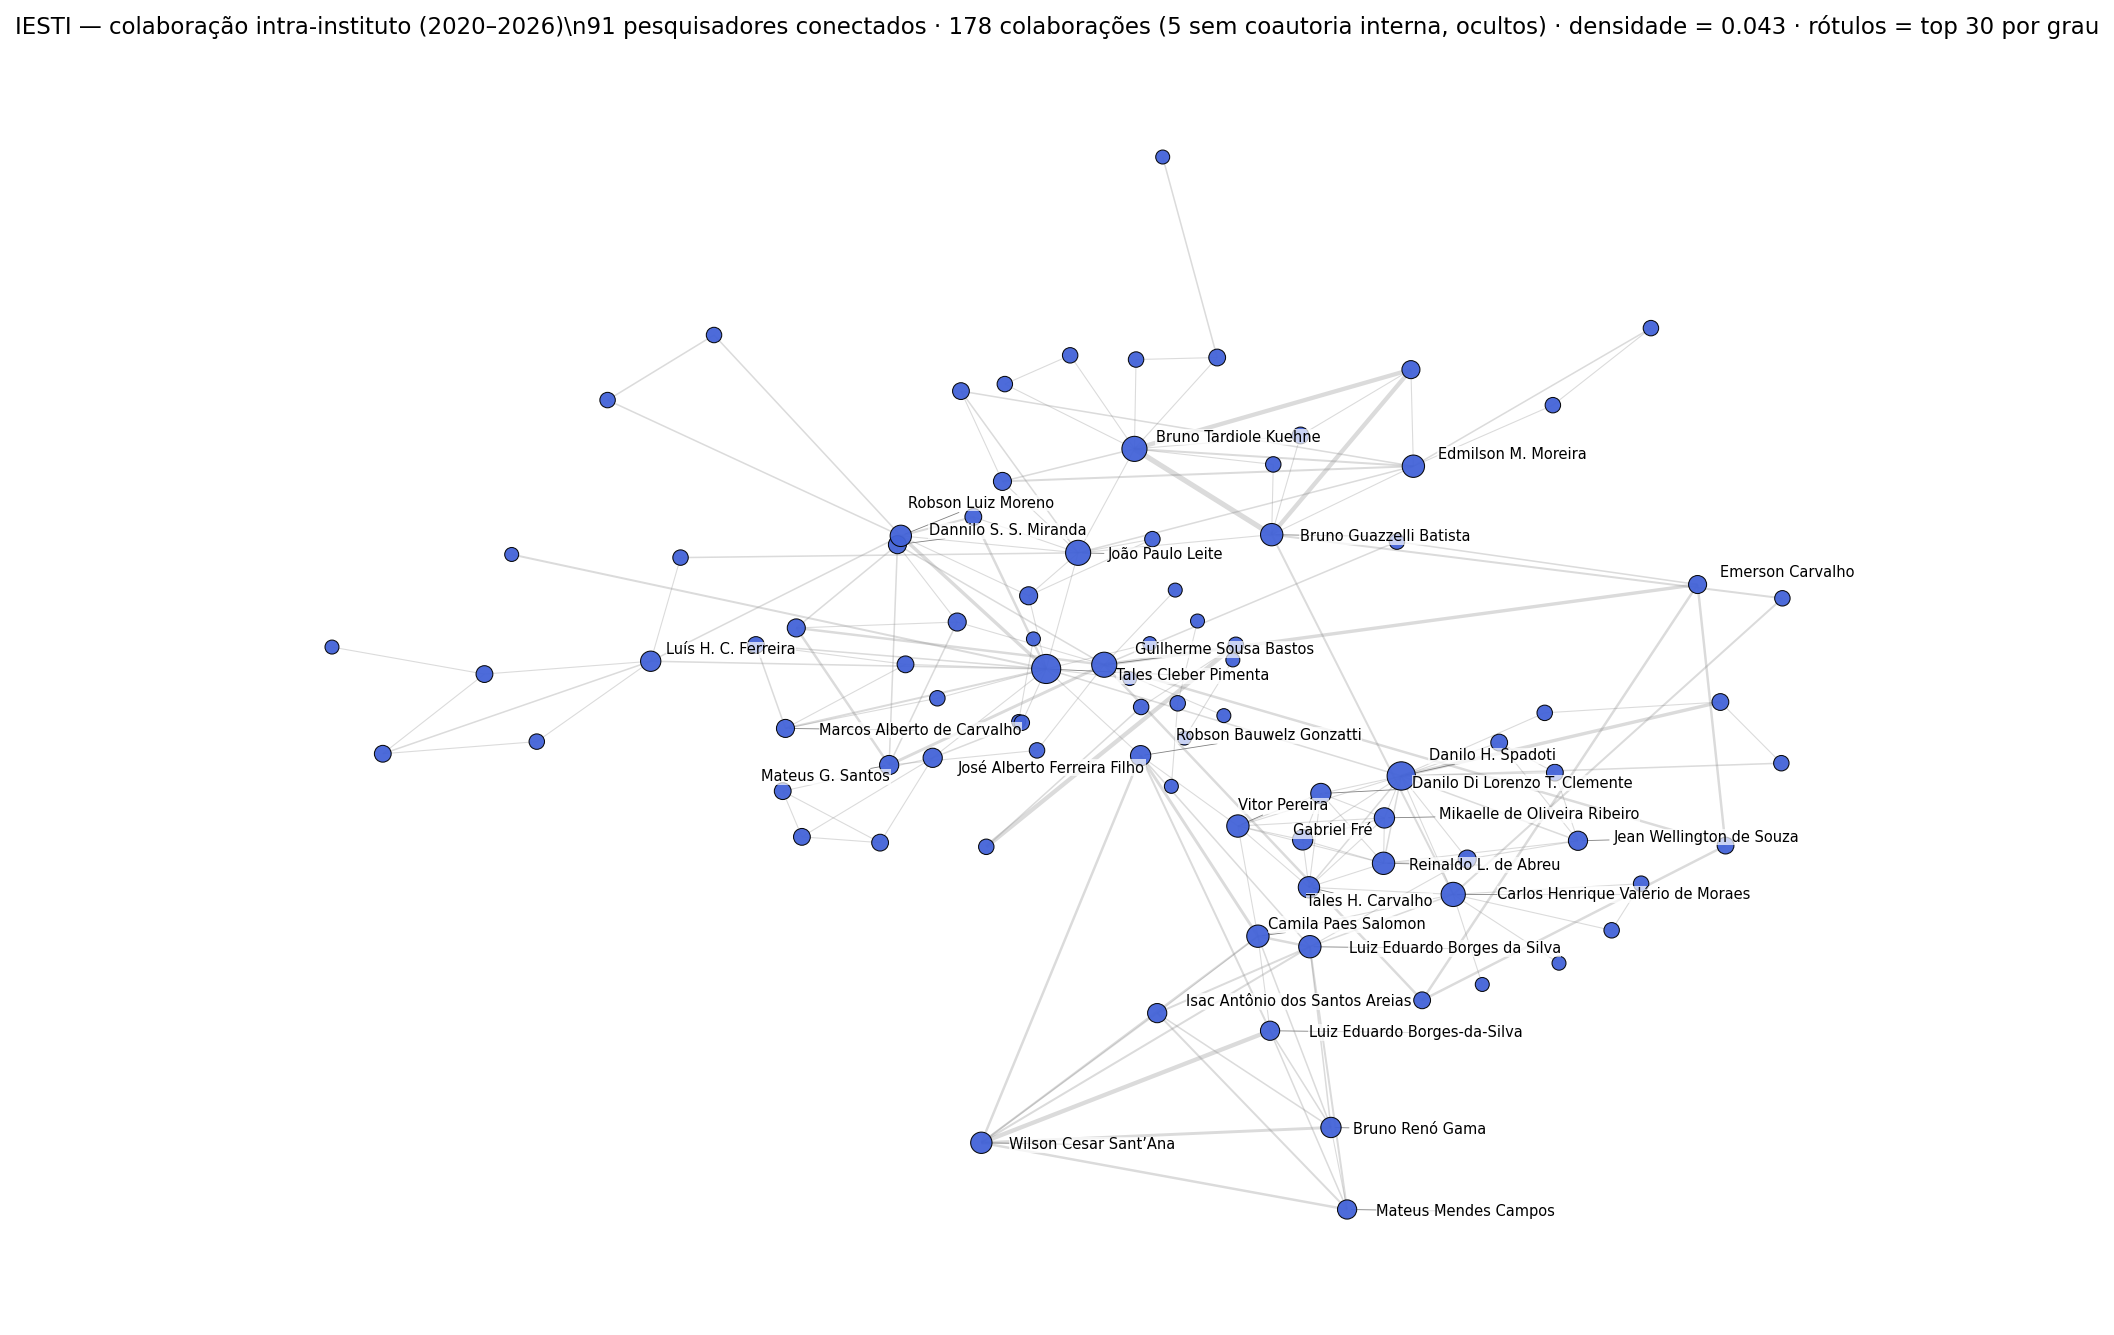

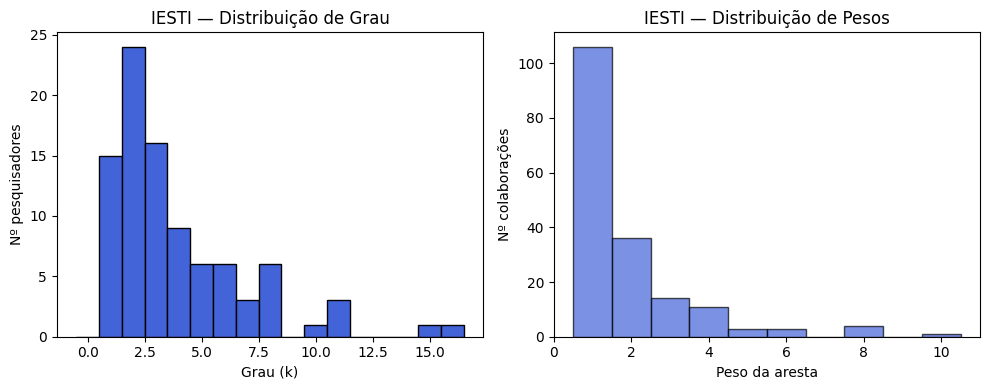

Salvo: IESTI_rede.png e IESTI_distribuicao.png (91 nós, 178 arestas)\n


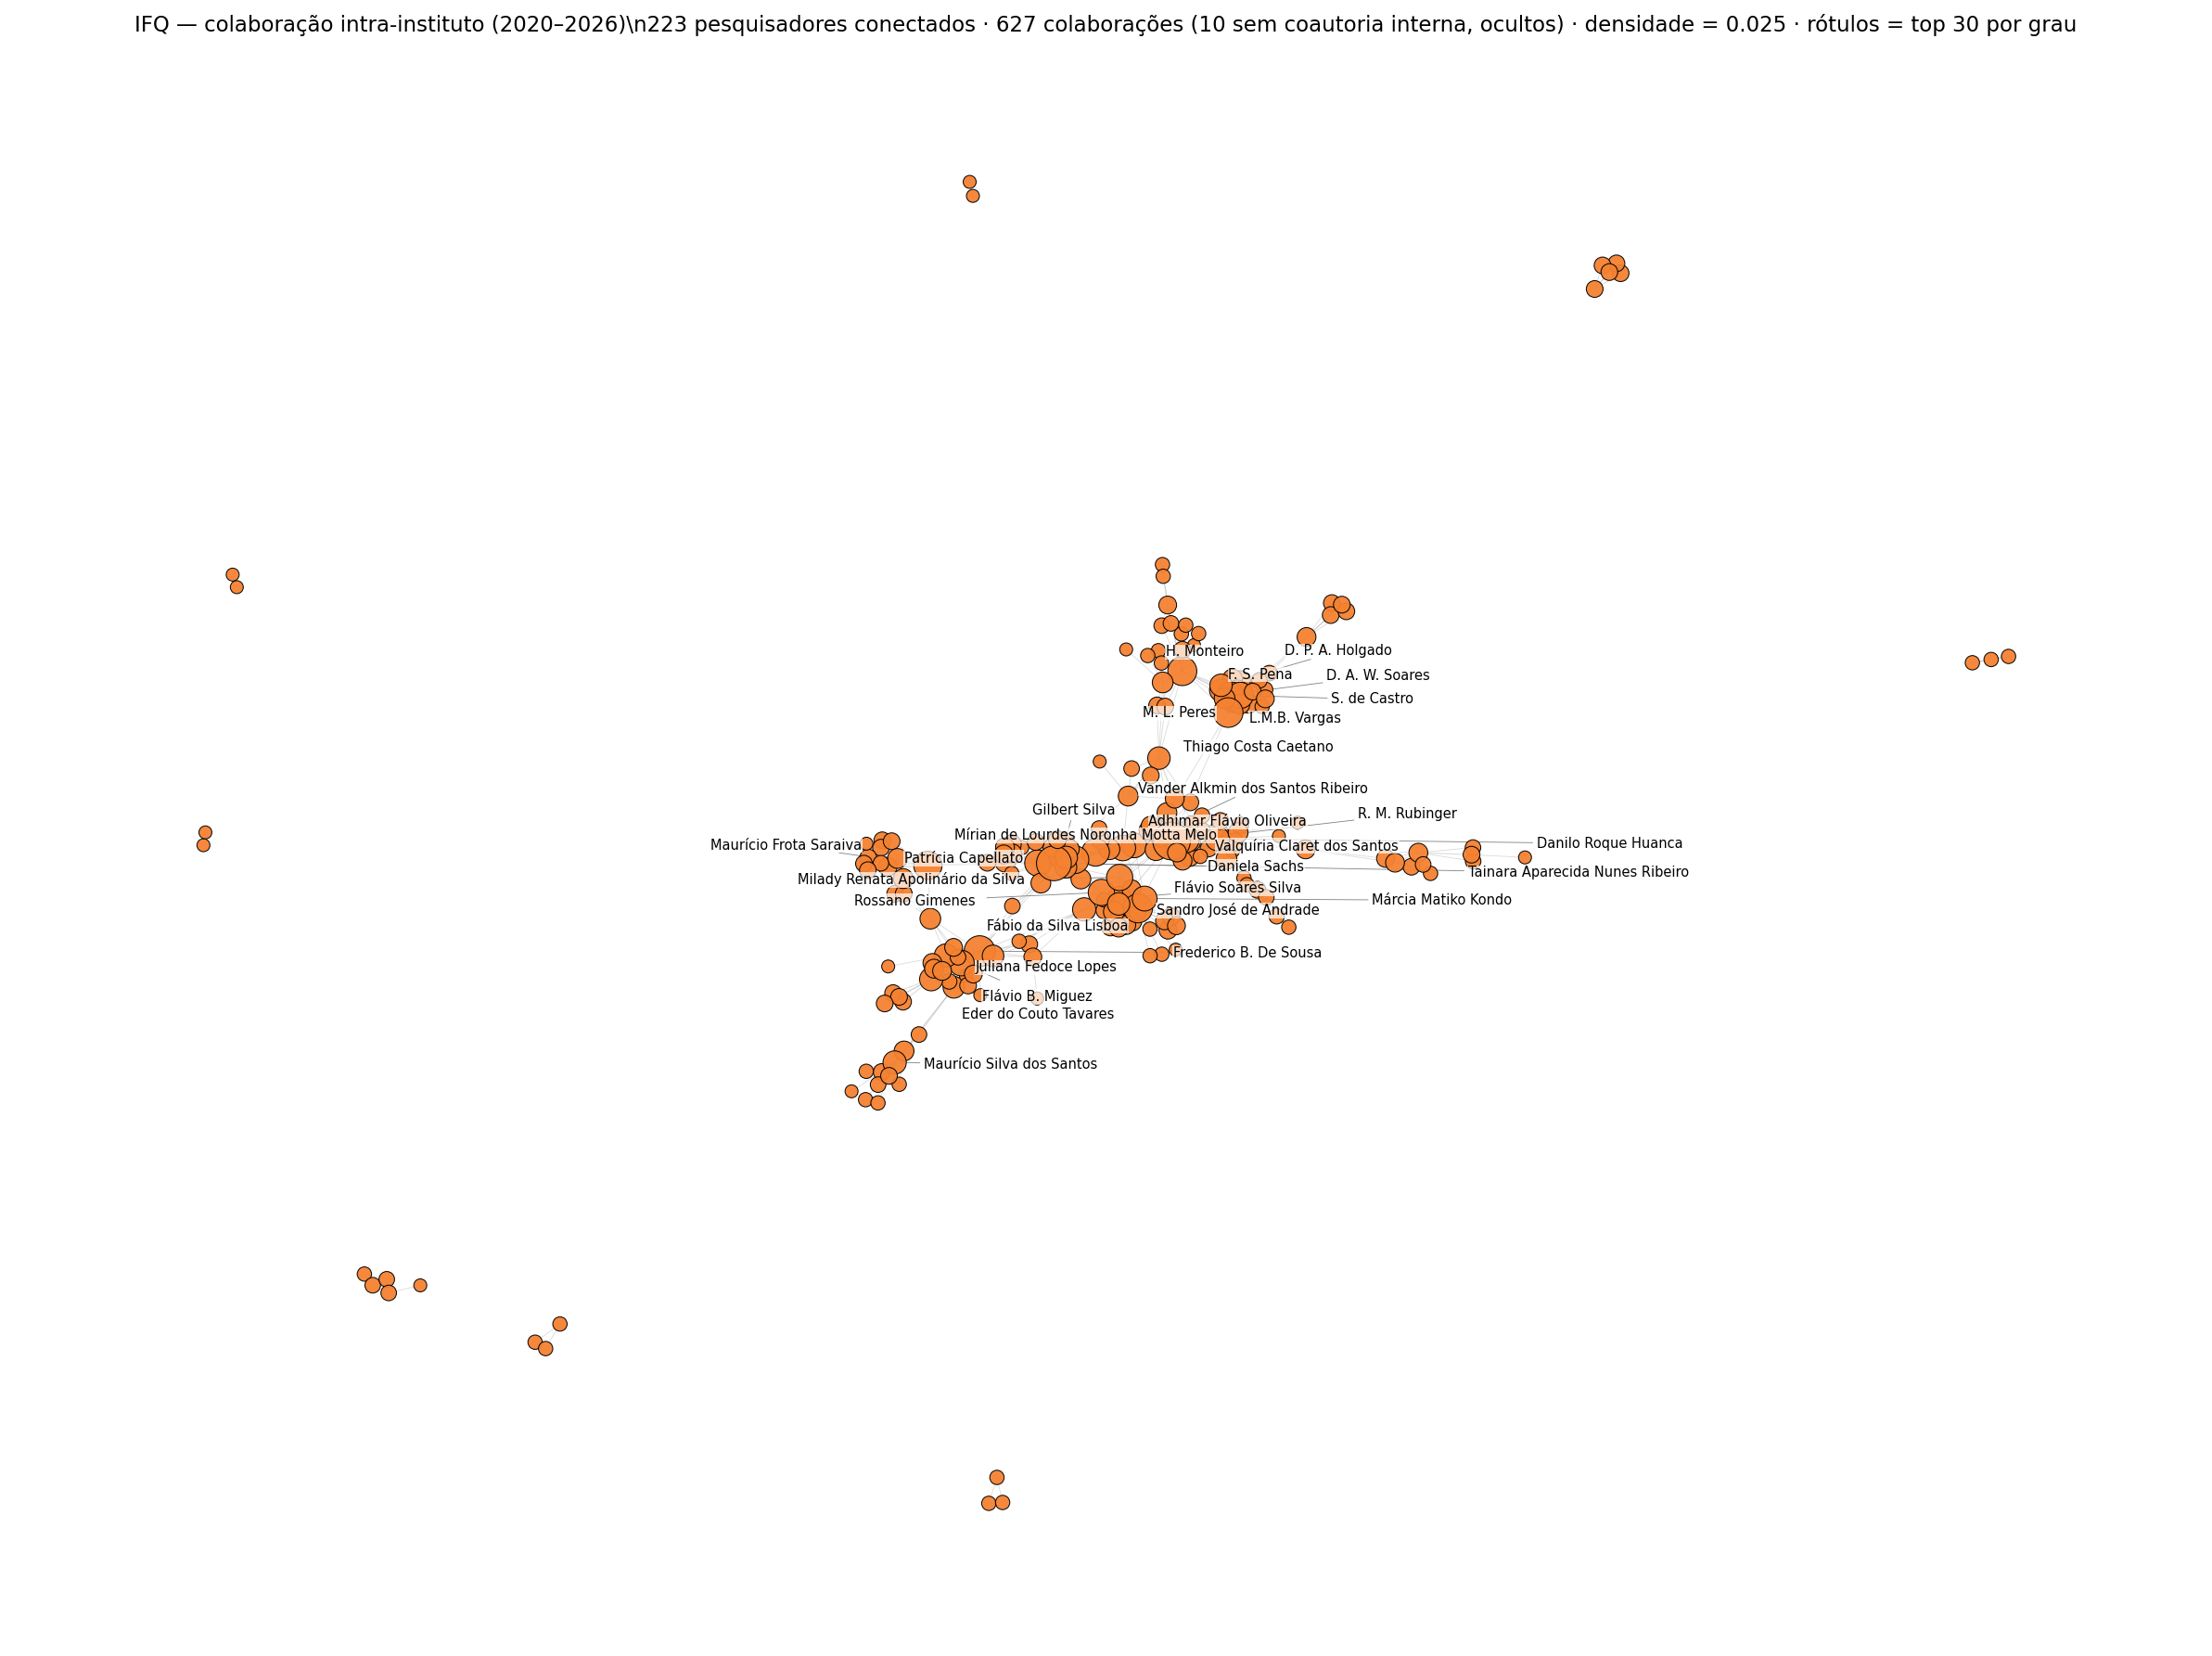

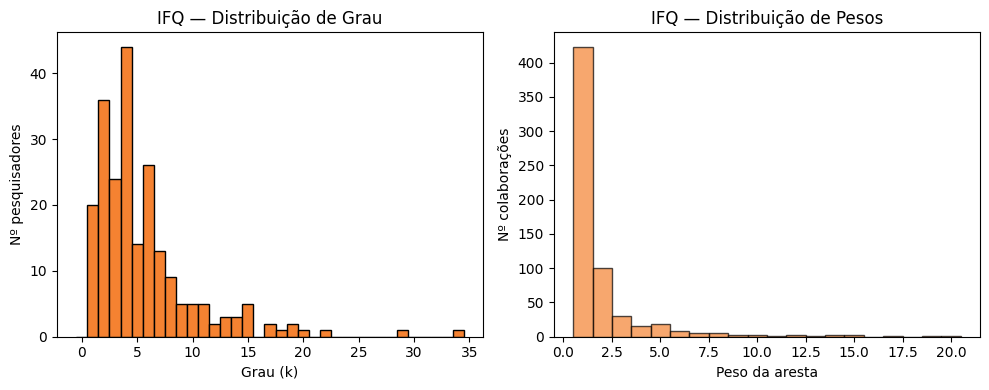

Salvo: IFQ_rede.png e IFQ_distribuicao.png (223 nós, 627 arestas)\n


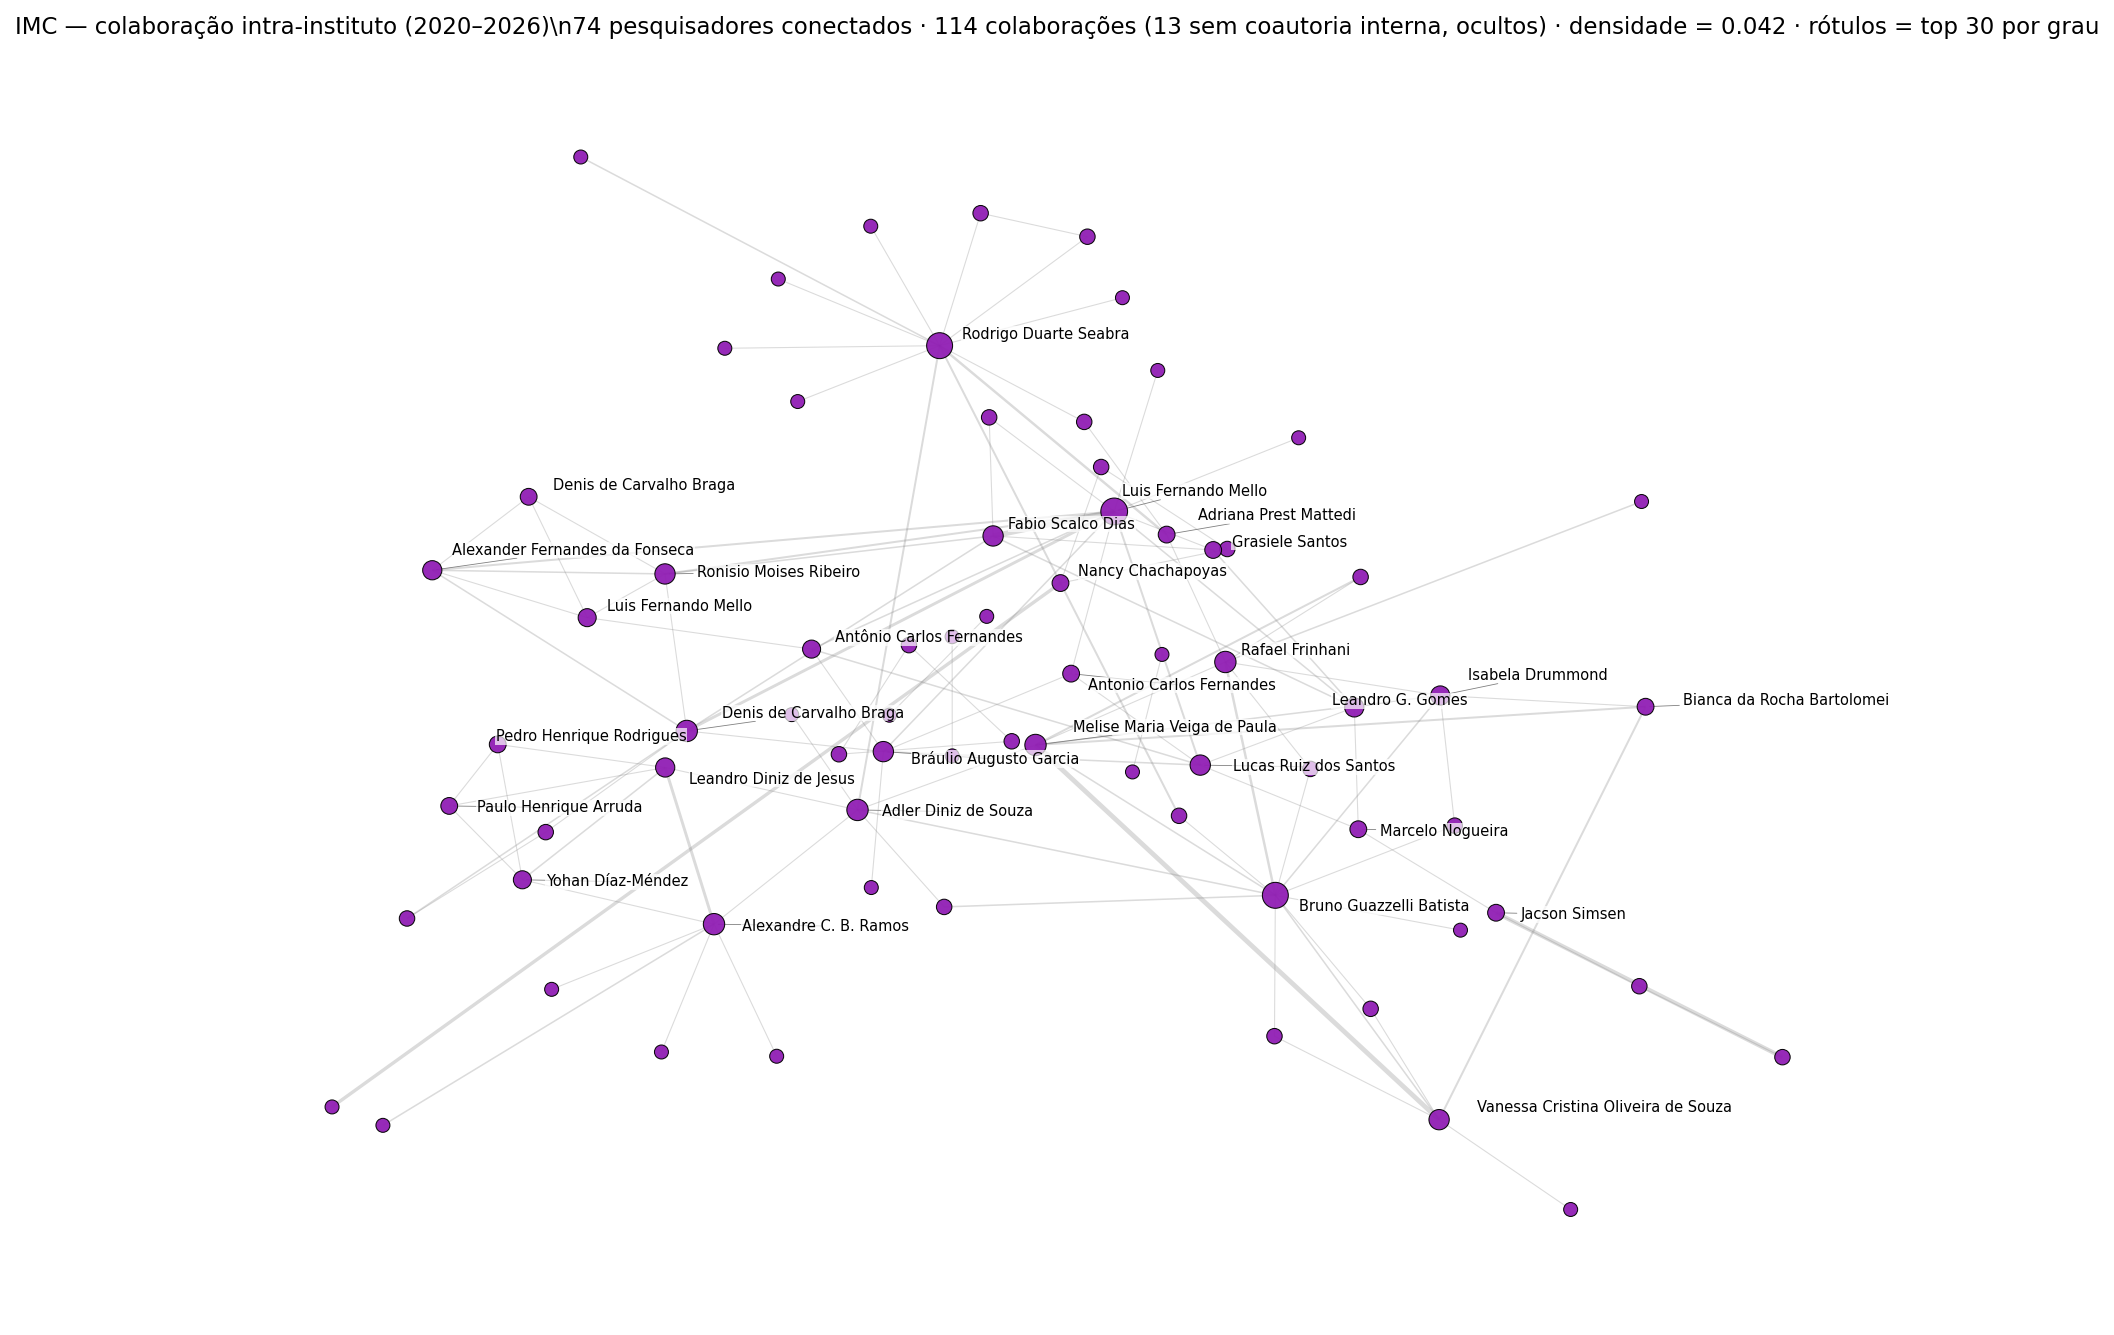

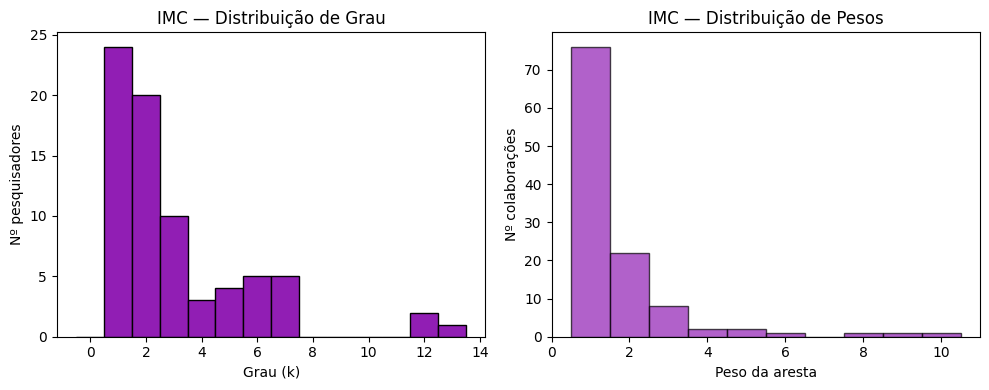

Salvo: IMC_rede.png e IMC_distribuicao.png (74 nós, 114 arestas)\n


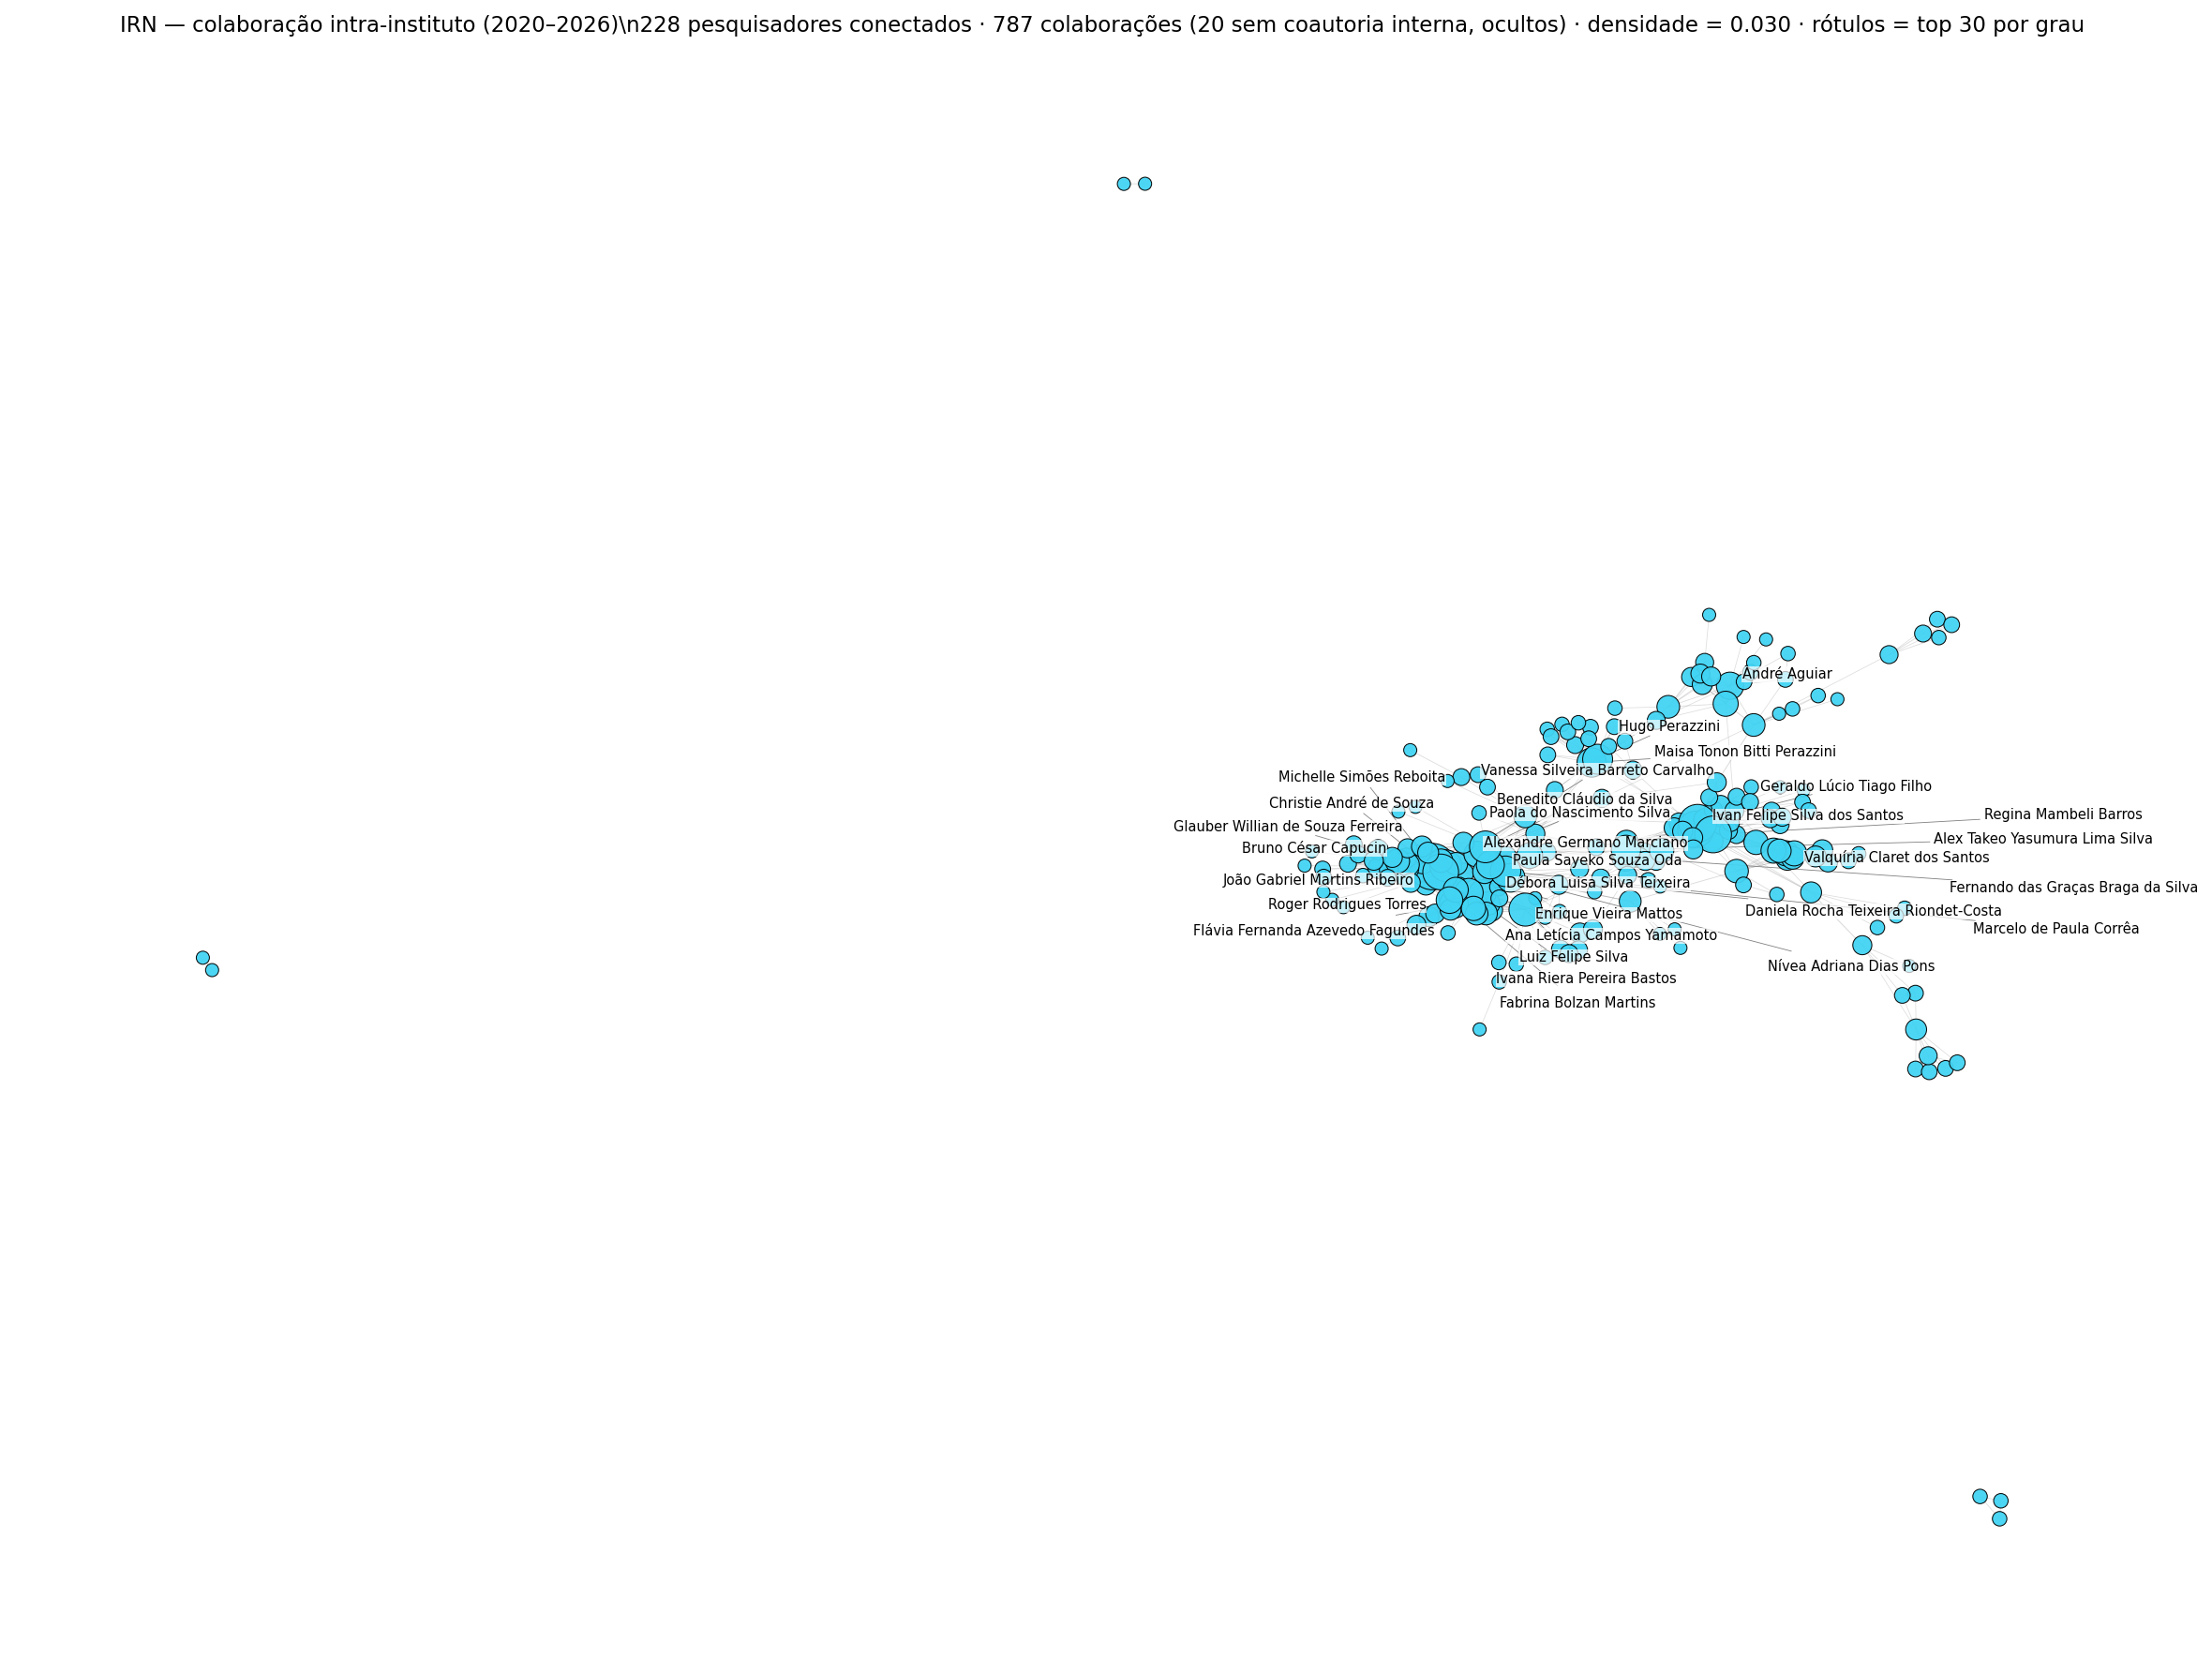

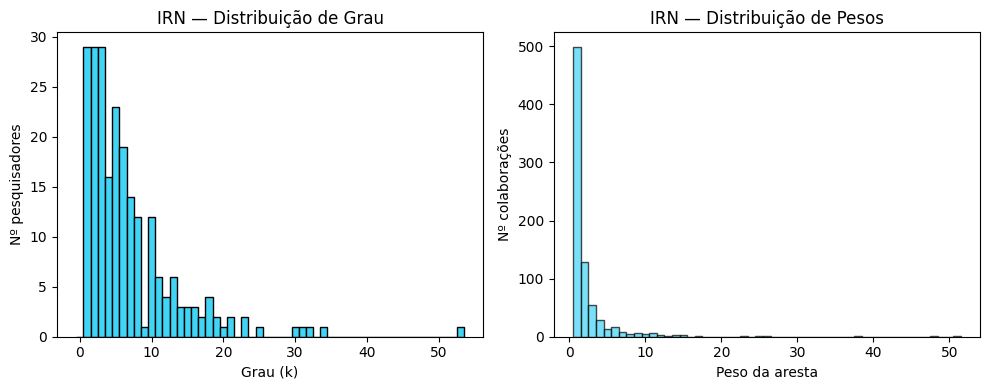

Salvo: IRN_rede.png e IRN_distribuicao.png (228 nós, 787 arestas)\n


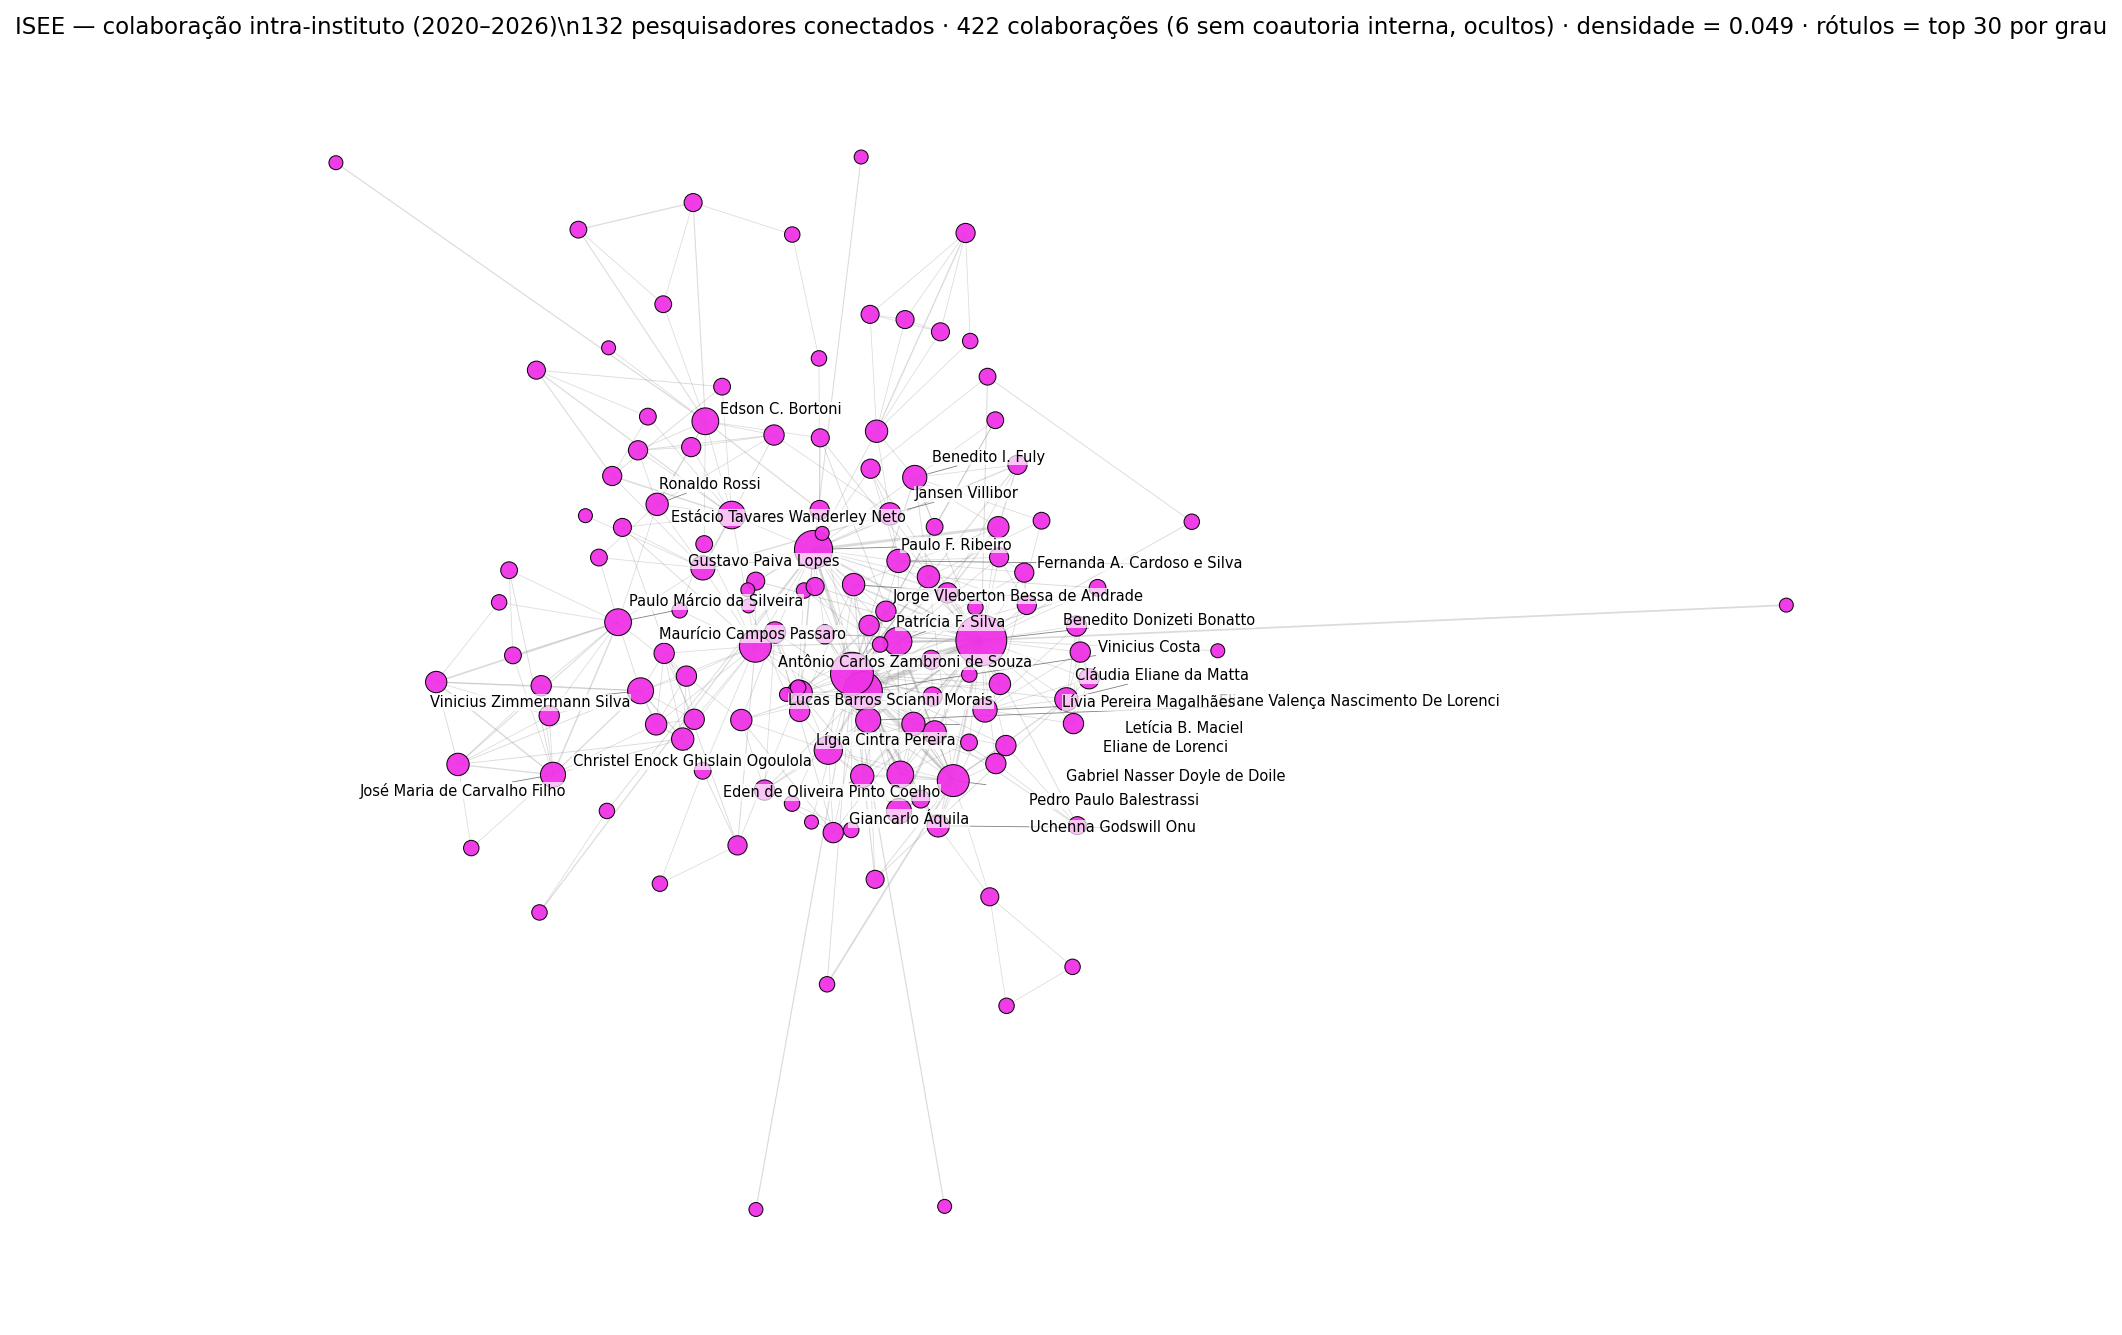

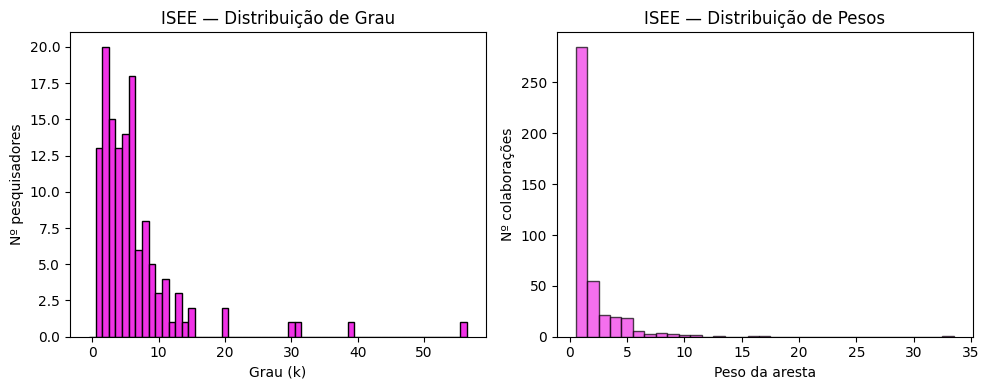

Salvo: ISEE_rede.png e ISEE_distribuicao.png (132 nós, 422 arestas)\n


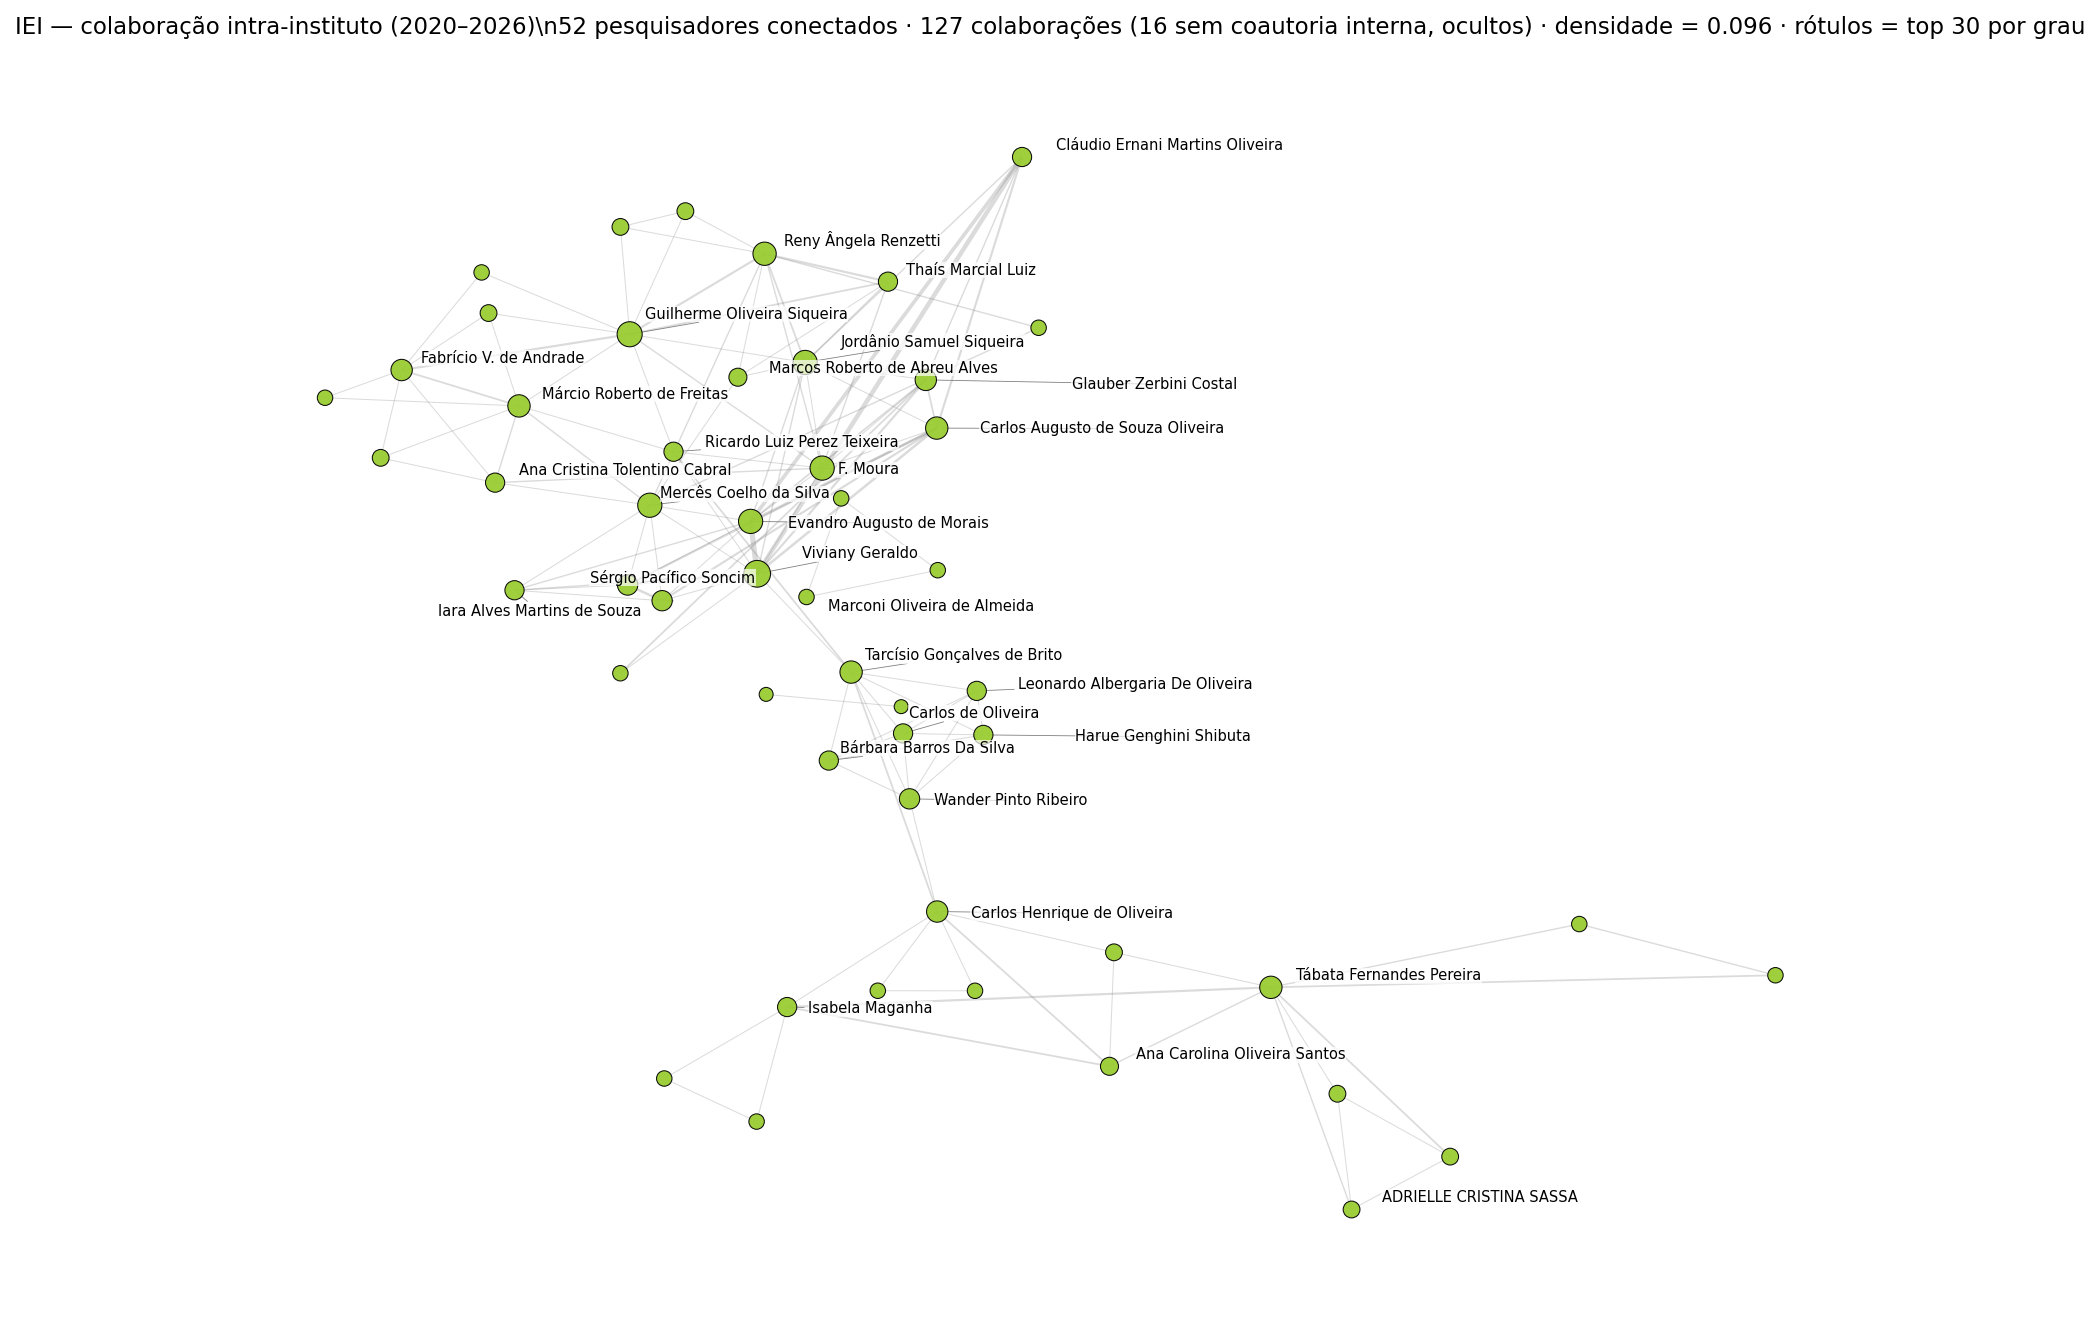

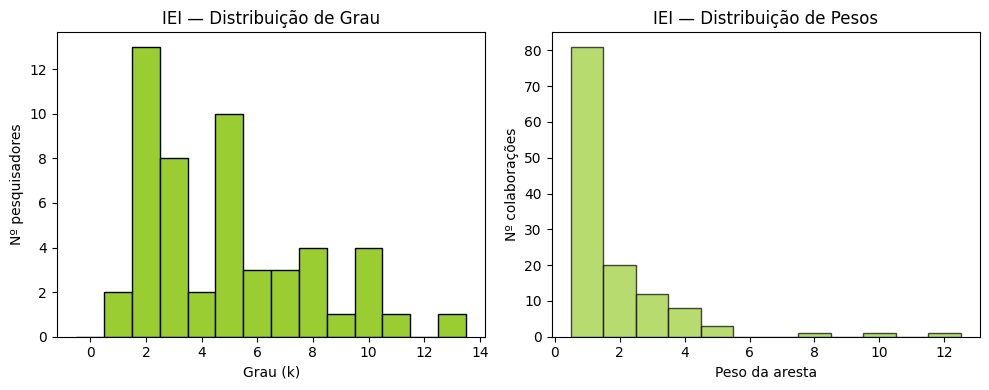

Salvo: IEI_rede.png e IEI_distribuicao.png (52 nós, 127 arestas)\n


In [ ]:
linhas_resumo = []

for sigla in INSTITUTOS:

    ids_instituto = set(nodes.loc[nodes["instituto"].str.contains(sigla, na=False), "id"])
    sub_edges = edges[edges["source"].isin(ids_instituto) & edges["target"].isin(ids_instituto)]

    Gi = nx.Graph()
    for _id in ids_instituto:
        label = nodes.loc[nodes["id"] == _id, "label"].values[0]
        Gi.add_node(_id, label=label)
    for _, row in sub_edges.iterrows():
        Gi.add_edge(row["source"], row["target"], weight=row["weight"])

    isolados = list(nx.isolates(Gi))
    Gi.remove_nodes_from(isolados)

    if Gi.number_of_nodes() == 0:
        print(f"{sigla}: sem colaborações intra-instituto, pulando.")
        continue

    # --- propriedades estruturais (mesmo padrão da AT2) ---
    props_i = propriedades_rede(Gi, sigla)
    props_i["Pesquisadores sem coautoria interna"] = len(isolados)
    linhas_resumo.append(props_i)

    # kamada_kawai separa melhor os clusters em grafos menores;
    # spring_layout é mais rápido/estável para os maiores
    if Gi.number_of_nodes() <= 220:
        try:
            pos_i = nx.kamada_kawai_layout(Gi)
        except Exception:
            pos_i = nx.spring_layout(Gi, k=2.2/np.sqrt(Gi.number_of_nodes()), iterations=150, seed=7)
    else:
        pos_i = nx.spring_layout(Gi, k=2.2/np.sqrt(Gi.number_of_nodes()), iterations=150, seed=7)

    graus_i = dict(Gi.degree())
    tamanho_fig = 12 if Gi.number_of_nodes() < 150 else 16

    fig, ax = plt.subplots(figsize=(tamanho_fig, tamanho_fig * 0.75), dpi=150)

    node_sizes_i = [35 + 10 * graus_i[n] for n in Gi.nodes()]
    edge_weights = [Gi[u][v]["weight"] for u, v in Gi.edges()]
    max_w = max(edge_weights) if edge_weights else 1
    edge_widths = [0.3 + 2.2 * (w / max_w) for w in edge_weights]

    nx.draw_networkx_edges(Gi, pos_i, ax=ax, alpha=0.3, width=edge_widths, edge_color="#888888")
    nx.draw_networkx_nodes(Gi, pos_i, ax=ax, node_color=CORES[sigla], node_size=node_sizes_i,
                            linewidths=0.5, edgecolors="black", alpha=0.95)

    top_n_labels = min(30, Gi.number_of_nodes())
    top_n = sorted(graus_i, key=graus_i.get, reverse=True)[:top_n_labels]

    texts_i = []
    for n in top_n:
        x, y = pos_i[n]
        texts_i.append(ax.text(x, y, Gi.nodes[n]["label"], fontsize=7,
                                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.3)))
    adjust_text(texts_i, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4))

    ax.set_title(
        f"{sigla} — colaboração intra-instituto (2020–2026)\\n"
        f"{Gi.number_of_nodes()} pesquisadores conectados · {Gi.number_of_edges()} colaborações "
        f"({len(isolados)} sem coautoria interna, ocultos) · densidade = {props_i['Densidade']:.3f} · "
        f"rótulos = top {top_n_labels} por grau",
        fontsize=11
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"/content/figuras/{sigla}_rede.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- histograma de grau + peso por instituto ---
    graus_lista_i = list(graus_i.values())
    pesos_lista_i = edge_weights

    fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
    axes2[0].hist(graus_lista_i, bins=range(0, max(graus_lista_i) + 2), color=CORES[sigla],
                  edgecolor="black", align="left")
    axes2[0].set_xlabel("Grau (k)")
    axes2[0].set_ylabel("Nº pesquisadores")
    axes2[0].set_title(f"{sigla} — Distribuição de Grau")

    axes2[1].hist(pesos_lista_i, bins=range(1, max(pesos_lista_i) + 2), color=CORES[sigla],
                  edgecolor="black", align="left", alpha=0.7)
    axes2[1].set_xlabel("Peso da aresta")
    axes2[1].set_ylabel("Nº colaborações")
    axes2[1].set_title(f"{sigla} — Distribuição de Pesos")

    plt.tight_layout()
    plt.savefig(f"/content/figuras/{sigla}_distribuicao.png", dpi=200)
    plt.show()

    print(f"Salvo: {sigla}_rede.png e {sigla}_distribuicao.png "
          f"({Gi.number_of_nodes()} nós, {Gi.number_of_edges()} arestas)\\n")

## 2.1 Tabela comparativa entre institutos

Consolida as métricas de todos os institutos (e da rede geral, para
referência) em uma única tabela — igual ao que foi feito individualmente na
AT2, mas lado a lado para comparação.

In [ ]:
resumo_institutos = pd.DataFrame(linhas_resumo).drop(
    columns=["_ca_local", "_pontos_articulacao", "_pontes"]
)

# Junta a linha da rede geral (maior componente) no topo, para referência
resumo_completo = pd.concat(
    [resumo_geral[resumo_geral["Rede"] == "Geral (maior componente)"], resumo_institutos],
    ignore_index=True
)

display(resumo_completo)

resumo_completo.to_csv("/content/figuras/02_tabela_comparativa_institutos.csv", index=False)
print("Salvo: 02_tabela_comparativa_institutos.csv")

,Rede,Nós,Links,Links (completo),Densidade,Grau médio <k>,Nº componentes conexos,Distância média <d> (maior comp.),Diâmetro (maior comp.),Coef. Agrupamento Médio,Coef. Agrupamento Global,Nº pontos de articulação,Nº arestas-ponte,Valor da rede (Metcalfe),Pesquisadores sem coautoria interna
0,Geral (maior componente),2987,10432,4459591,0.0023,6.9849,1,5.0340,13,0.6955,0.2569,268,350,8922169,NaN
1,IEM,179,593,15931,0.0372,6.6257,7,3.7581,8,0.7057,0.4567,16,15,32041,20.0
2,IEPG,133,467,8778,0.0532,7.0226,4,3.0470,7,0.5508,0.3307,11,16,17689,2.0
3,IESTI,91,178,4095,0.0435,3.9121,6,3.2852,7,0.6300,0.4299,12,13,8281,5.0
4,IFQ,223,627,24753,0.0253,5.6233,9,4.1340,9,0.7155,0.4362,21,17,49729,10.0
5,IMC,74,114,2701,0.0422,3.0811,7,2.9730,5,0.4524,0.3133,12,22,5476,13.0
6,IRN,228,787,25878,0.0304,6.9035,4,3.7464,8,0.6355,0.3756,21,29,51984,20.0
7,ISEE,132,422,8646,0.0488,6.3939,4,2.9330,7,0.6868,0.3305,7,11,17424,6.0
8,IEI,52,127,1326,0.0958,4.8846,3,3.4709,7,0.7319,0.5139,4,1,2704,16.0


Salvo: 02_tabela_comparativa_institutos.csv


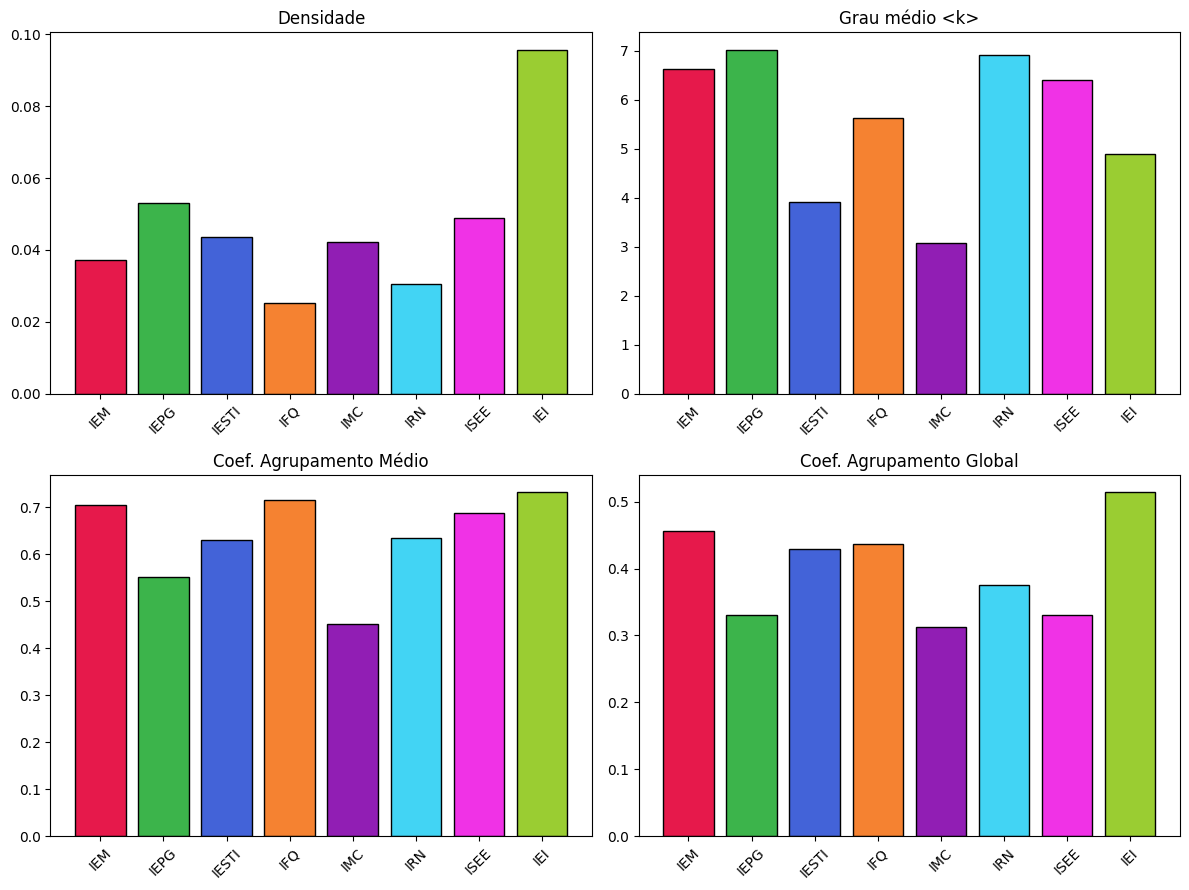

In [ ]:
# ============================================================
# GRÁFICOS COMPARATIVOS ENTRE INSTITUTOS
# ============================================================

comparar = resumo_institutos.set_index("Rede")
metricas_para_comparar = ["Densidade", "Grau médio <k>", "Coef. Agrupamento Médio",
                           "Coef. Agrupamento Global"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, metrica in zip(axes.flat, metricas_para_comparar):
    cores_barras = [CORES[i] for i in comparar.index]
    ax.bar(comparar.index, comparar[metrica], color=cores_barras, edgecolor="black")
    ax.set_title(metrica)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("/content/figuras/03_comparativo_institutos.png", dpi=200)
plt.show()

## 3. Download de tudo (figuras + estatísticas) em um `.zip`

In [ ]:
import shutil
from google.colab import files
import zipfile

zip_path = "/content/figuras_redes_com_estatisticas.zip"

with zipfile.ZipFile(zip_path, "w") as z:
    for arquivo in os.listdir("/content/figuras"):
        z.write(os.path.join("/content/figuras", arquivo), arquivo)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>